# High-Frequency Inverse-Problem PINN Experiment Based on JAX

## Advection Equation, Diagnostic Analysis, and Inverse-Parameter Initialization

### Research Question

This notebook studies the following question: for the one-dimensional advection equation, can a PINN simultaneously learn the high-frequency solution

$$
u(x,t)=\sin(2\pi k(x-ct))$$

and the unknown wave speed $c$?

## Abstract

This report studies the inverse problem for the one-dimensional high-frequency advection equation:

$$u_t+c u_x=0, \qquad c>0.$$

The true solution is set to be

$$u(x,t)=\sin(2\pi k(x-ct)),$$

where $k=8$, and the unknown parameter is the wave speed $c$. The goal is to use a small amount of observation data, the initial condition, the boundary condition, and PDE collocation points to learn both the solution $u(x,t)$ and the parameter $c$.

The main conclusion is that a high-frequency inverse PINN has two different levels of difficulty:

1. whether the network can represent a high-frequency oscillatory function;
2. whether the training process can move the unknown parameter $c$ into the correct basin.

Fourier features can improve high-frequency representation, and a hard periodic embedding can structurally enforce the periodic boundary condition. However, these techniques do not guarantee that $c$ will be correctly identified. In contrast, grid initialization based on the characteristic formula, combined with two-stage training, is the most effective method for identifying $c$. This result shows that **the failure of a high-frequency inverse PINN is not only a representation problem, but also an inverse-parameter optimization problem.**


## 0. Package Imports and JAX Setup

In this experiment, JAX is used not only for writing the neural network, but also as a differentiable scientific computing tool. Its main roles are:

- using `jax.grad` to automatically compute $u_x$ and $u_t$, and therefore construct the PDE residual;
- using `jax.value_and_grad` to compute gradients with respect to both the network parameters $\theta$ and the inverse-problem parameter $c$;
- using `jax.vmap` to batch-compute residuals, characteristic losses, and NTK sample values over many training points;
- using `jax.jit` to compile the training step and improve execution speed;
- using `jax.jacrev` to compute the empirical output NTK and the PDE residual NTK.


In [1]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

# os.environ["JAX_PLATFORM_NAME"] = "cpu"

import math
import time
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", False)  # float32
import jax.numpy as jnp
from jax import random
from jax.flatten_util import ravel_pytree

print("JAX version:", jax.__version__)
print("Backend:", jax.default_backend())
print("Devices:", jax.devices())

JAX version: 0.10.2
Backend: cpu
Devices: [CpuDevice(id=0)]


## 1. Research Motivation and Mathematical Setup

Many PINN examples are forward problems: the PDE parameters are known, and the only goal is to solve for $u(x,t)$. Here we study an inverse problem: the PDE form is known, but the wave speed $c$ is unknown, and it must be inferred from a small amount of observation data together with PDE constraints.

We consider

$$u_t+c u_x=0,\qquad x\in[0,1],\quad t\in[0,T].$$

For the linear advection equation, the solution is transported along characteristic lines. If the initial profile is $u_0(x)$, then

$$u(x,t;c)=u_0(x-ct).$$

In this experiment, we choose the high-frequency initial profile

$$u(x,t)=\sin(2\pi k(x-c_{\mathrm{true}}t)),$$

with the default setting

$$k=8,\qquad c_{\mathrm{true}}=1.30.$$

The difficulty comes from the phase term $2\pi k(x-ct)$. When $k$ is large, a small error in $c$ is amplified by the frequency $k$, causing a global phase shift in the wave field. Therefore, the loss landscape of this inverse problem can easily contain multiple local basins. The characteristic baseline below will directly demonstrate this phenomenon.


In [2]:
# -------------------------
# Global experiment settings
# -------------------------
KEY = random.PRNGKey(42)

# Main PDE parameters
K_FREQ = 8
C_TRUE = 1.30
T_FINAL = 0.50

# Experiment scale.
# - "debug": fast smoke test; use this if the kernel is unstable.
# - "standard": balanced run
# - "strong": larger network, more points, and more training steps.
SCALE = "strong"

if SCALE == "debug":
    N_F = 48       # PDE collocation points
    N_IC = 24       # initial-condition points
    N_BC = 24       # boundary points for soft periodic BC
    N_DATA = 24     # sparse data points
    N_STEPS = 80
    WIDTH = 16
    DEPTH = 2
    NTK_N = 6
    RAR_CANDIDATES = 128
    RAR_ADD = 32
    N_RES_EVAL = 48
elif SCALE == "standard":
    N_F = 256
    N_IC = 64
    N_BC = 64
    N_DATA = 64
    N_STEPS = 1500
    WIDTH = 48
    DEPTH = 2
    NTK_N = 16
    RAR_CANDIDATES = 512
    RAR_ADD = 96
    N_RES_EVAL = 160
elif SCALE == "strong":
    N_F = 1024
    N_IC = 256
    N_BC = 256
    N_DATA = 256
    N_STEPS = 30000
    WIDTH = 64
    DEPTH = 4
    NTK_N = 24
    RAR_CANDIDATES = 2048
    RAR_ADD = 256
    N_RES_EVAL = 448
else:
    raise ValueError("SCALE must be one of: debug, standard, strong")

# Independent validation data for selecting inverse-parameter initializations.
# It is not used in the training loss.
N_VAL = max(128, 2 * N_DATA)

PRINT_EVERY = max(100, N_STEPS // 8)

# Optional expensive parts. Full NTK is the heaviest one;
RUN_NTK = True                 # Full empirical output NTK with respect to all network parameters.
RUN_ADAPTIVE_LOSS_WEIGHTING = False  # old placeholder; implemented later as RUN_ADAPTIVE_GRAD_WEIGHTING
RUN_RAR = True
RUN_GRID_INIT_PINN = True      # Train a PINN initialized from the characteristic grid-search estimate of c.
RUN_MULTISTART_PINN = True    # Try several initial values of c and continue from the best short run.
RUN_FREQUENCY_CURRICULUM = True  # Train from low frequency to high frequency: 1 -> 2 -> 4 -> K_FREQ.

# RAR settings
RAR_PRETRAIN_FRACTION = 0.5

# Adaptive loss weighting settings
REWEIGHT_EVERY = max(250, N_STEPS // 4)
LOSS_WEIGHT_CLIP = (0.2, 50.0)

# Coarse/fine grid search for c initialization. This part is cheap compared with PINN training.
C_GRID_MIN = 0.1
C_GRID_MAX = 2.5
C_GRID_COARSE_N = 120
C_GRID_FINE_N = 80
C_GRID_FINE_RADIUS = 0.04

# Two-stage training after grid initialization.
# Stage 1 fixes c=c0 and trains only the network, so the early unstable network does not pull c away.
# Stage 2 unfreezes c and fine-tunes it with a smaller learning rate.
GRID_STAGE1_FRACTION = 0.70
GRID_STAGE1_STEPS = max(1, int(GRID_STAGE1_FRACTION * N_STEPS))
GRID_STAGE2_STEPS = max(1, N_STEPS - GRID_STAGE1_STEPS)
GRID_STAGE1_LR_PARAMS = 1e-3
GRID_STAGE2_LR_PARAMS = 1e-3
GRID_STAGE2_LR_C = 2e-4

# Multi-start settings for the inverse parameter c.
# The short runs are used only for selecting a promising basin.
MULTISTART_C_INITS = [0.30, 0.70, 1.10, 1.30, 1.70, 2.10]
MULTISTART_SHORT_STEPS = max(300, N_STEPS // 5)

# Selection rule for the best multi-start short run.
# Options:
# - "validation_data": choose the short-run model with the smallest held-out data MSE.
# - "characteristic": choose the short-run model whose final c minimizes the scalar characteristic loss.
# - "combined": use validation_data + characteristic as a conservative criterion.
MULTISTART_SELECTION = "characteristic"

# Frequency curriculum settings.
# Total curriculum steps are approximately N_STEPS, so it is comparable to a direct high-frequency run.
CURRICULUM_K_LIST = [1, 2, 4, K_FREQ]
CURRICULUM_STEPS_PER_STAGE = max(150, N_STEPS // len(CURRICULUM_K_LIST))

DEFAULT_WEIGHTS = {
    "pde": 1.0,
    "ic": 10.0,
    "bc": 1.0,
    "data": 10.0,
}

HARD_BC_WEIGHTS = {
    "pde": 1.0,
    "ic": 10.0,
    "bc": 0.0,   # hard periodic model does not need soft BC loss
    "data": 10.0,
}

def exact_u(x, t, c=C_TRUE, k=K_FREQ):
    return jnp.sin(2.0 * jnp.pi * k * (x - c * t))

def inv_softplus(y):
    y = jnp.asarray(y, dtype=jnp.float32)
    return jnp.log(jnp.expm1(y))

def positive(raw):
    # We parameterize c = softplus(raw_c) so that c > 0.
    return jax.nn.softplus(raw)

def tree_l2_norm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    return jnp.sqrt(sum([jnp.sum(x**2) for x in leaves]))

print("SCALE =", SCALE)
print("k =", K_FREQ, "c_true =", C_TRUE)
print("N_STEPS =", N_STEPS, "WIDTH =", WIDTH, "DEPTH =", DEPTH, "N_F =", N_F, "N_DATA =", N_DATA)
print("NTK_N =", NTK_N)


SCALE = strong
k = 8 c_true = 1.3
N_STEPS = 30000 WIDTH = 64 DEPTH = 4 N_F = 1024 N_DATA = 256
NTK_N = 24


## 2. Training Data

To make the problem genuinely inverse, training does not use only the PDE; it also includes a small amount of observation data. The training data are divided into four types:

1. **PDE collocation points** $(x_f,t_f)$: these points have no ground-truth labels. They only require the residual to be small:

   $$r_\theta(x,t)=\partial_tu_\theta(x,t)+c\partial_xu_\theta(x,t).$$

2. **Initial-condition points**: these require

   $$u_\theta(x,0)\approx \sin(2\pi kx).$$

3. **Periodic boundary points**: the soft-boundary PINN uses

   $$u_\theta(0,t)\approx u_\theta(1,t).$$

4. **Sparse observation data**: a small number of $(x_i,t_i,u_i)$ values are used to help identify the unknown parameter $c$. Without the data loss, many different solutions may satisfy the PDE, so the inverse problem can become unidentifiable.

A validation set is also built to evaluate model performance outside the training points.


In [3]:
def make_training_data(key):
    key_f, key_bc, key_data = random.split(key, 3)
    key_xf, key_tf = random.split(key_f)
    key_xd, key_td = random.split(key_data)

    # PDE collocation points in [0,1] x [0,T]
    x_f = random.uniform(key_xf, (N_F, 1), minval=0.0, maxval=1.0)
    t_f = random.uniform(key_tf, (N_F, 1), minval=0.0, maxval=T_FINAL)
    xt_f = jnp.concatenate([x_f, t_f], axis=1)

    # Initial condition points
    x_ic = jnp.linspace(0.0, 1.0, N_IC).reshape(-1, 1)
    t_ic = jnp.zeros_like(x_ic)
    xt_ic = jnp.concatenate([x_ic, t_ic], axis=1)
    y_ic = exact_u(x_ic[:, 0], t_ic[:, 0])

    # Periodic boundary points for soft boundary loss
    t_bc = random.uniform(key_bc, (N_BC, 1), minval=0.0, maxval=T_FINAL)
    xt_b0 = jnp.concatenate([jnp.zeros_like(t_bc), t_bc], axis=1)
    xt_b1 = jnp.concatenate([jnp.ones_like(t_bc), t_bc], axis=1)

    # Sparse observation data for inverse problem
    x_data = random.uniform(key_xd, (N_DATA, 1), minval=0.0, maxval=1.0)
    t_data = random.uniform(key_td, (N_DATA, 1), minval=0.0, maxval=T_FINAL)
    xt_data = jnp.concatenate([x_data, t_data], axis=1)
    y_data = exact_u(x_data[:, 0], t_data[:, 0])

    return {
        "xt_f": xt_f,
        "xt_ic": xt_ic,
        "y_ic": y_ic,
        "xt_b0": xt_b0,
        "xt_b1": xt_b1,
        "xt_data": xt_data,
        "y_data": y_data,
    }

batch = make_training_data(KEY)

def make_validation_data(key, n_val=N_VAL):
    """Independent validation data for inverse-parameter selection.

    These points are not used in the PINN training loss. They are used only to
    select between short multi-start runs.
    """
    key_x, key_t = random.split(key)
    x_val = random.uniform(key_x, (n_val, 1), minval=0.0, maxval=1.0)
    t_val = random.uniform(key_t, (n_val, 1), minval=0.0, maxval=T_FINAL)
    xt_val = jnp.concatenate([x_val, t_val], axis=1)
    y_val = exact_u(x_val[:, 0], t_val[:, 0])
    return {"xt_val": xt_val, "y_val": y_val}

validation_batch = make_validation_data(random.PRNGKey(202407))

for name, value in batch.items():
    print(f"{name:8s}", value.shape)
for name, value in validation_batch.items():
    print(f"{name:8s}", value.shape)

xt_f     (1024, 2)
xt_ic    (256, 2)
y_ic     (256,)
xt_b0    (256, 2)
xt_b1    (256, 2)
xt_data  (256, 2)
y_data   (256,)
xt_val   (512, 2)
y_val    (512,)


## 3. Model Architecture and Input Features

The main component of every method is an MLP, denoted by

$$u_\theta(x,t).$$

To identify the source of failure, the experiment defines three input representations. In each experiment, we try to change only one factor at a time.

### 3.1 Standard input

The standard PINN directly takes

$$z=(x,t).$$

This is the cleanest baseline. If it fails, then we have a reason to introduce more complex methods.

### 3.2 Fourier-feature input

Ordinary MLPs often have spectral bias for high-frequency functions. Therefore, we can first map the input into sine/cosine features:

$$
\gamma(x,t)=
[x,t,\sin(2\pi f_jx),\cos(2\pi f_jx),\sin(2\pi f_jt),\cos(2\pi f_jt)]_{j=1}^m.
$$

This step mainly tests: **is high-frequency representation ability the main bottleneck?**

### 3.3 Hard-periodic Fourier input

For a periodic boundary condition, we can directly encode periodicity into the input features. We remove the raw $x$ coordinate and use only periodic features of $x$:

$$
\gamma_{\mathrm{per}}(x,t)=
[t,\sin(2\pi f_jx),\cos(2\pi f_jx)]_{j=1}^m.
$$

Because the sine/cosine features at $x=0$ and $x=1$ are identical, the model satisfies the periodic boundary condition by construction. This step mainly tests: **is the boundary condition the main bottleneck?**


In [4]:
def init_mlp_params(key, layer_sizes):
    keys = random.split(key, len(layer_sizes) - 1)
    params = []
    for k, m, n in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
        limit = math.sqrt(6.0 / (m + n))
        W = random.uniform(k, (m, n), minval=-limit, maxval=limit)
        b = jnp.zeros((n,), dtype=jnp.float32)
        params.append({"W": W, "b": b})
    return params

def mlp_apply(params, z):
    h = z
    for layer in params[:-1]:
        h = jnp.tanh(h @ layer["W"] + layer["b"])
    out = h @ params[-1]["W"] + params[-1]["b"]
    return out[:, 0]

def standard_embed(xt):
    return xt

FOURIER_FREQS = jnp.array([1.0, 2.0, 4.0, 8.0, 16.0], dtype=jnp.float32)

def fourier_embed(xt):
    # Soft-boundary Fourier features: includes raw x, so periodic BC is not automatic.
    x = xt[:, 0:1]
    t = xt[:, 1:2]
    args_x = 2.0 * jnp.pi * x * FOURIER_FREQS[None, :]
    args_t = 2.0 * jnp.pi * t * FOURIER_FREQS[None, :]
    return jnp.concatenate(
        [x, t, jnp.sin(args_x), jnp.cos(args_x), jnp.sin(args_t), jnp.cos(args_t)],
        axis=1,
    )

def hard_periodic_fourier_embed(xt):
    # No raw x is included. x=0 and x=1 have identical x-features.
    x = xt[:, 0:1]
    t = xt[:, 1:2]
    args_x = 2.0 * jnp.pi * x * FOURIER_FREQS[None, :]
    args_t = 2.0 * jnp.pi * t * FOURIER_FREQS[None, :]
    return jnp.concatenate(
        [t, jnp.sin(args_x), jnp.cos(args_x), jnp.sin(args_t), jnp.cos(args_t)],
        axis=1,
    )

def make_apply_fn(embed_fn):
    def apply_fn(params, xt):
        return mlp_apply(params, embed_fn(xt))
    return apply_fn

standard_apply = make_apply_fn(standard_embed)
fourier_apply = make_apply_fn(fourier_embed)
hard_periodic_apply = make_apply_fn(hard_periodic_fourier_embed)

STD_INPUT_DIM = 2
FOURIER_INPUT_DIM = int(2 + 4 * len(FOURIER_FREQS))
HARD_PERIODIC_INPUT_DIM = int(1 + 4 * len(FOURIER_FREQS))

print("standard input dim:", STD_INPUT_DIM)
print("fourier input dim:", FOURIER_INPUT_DIM)
print("hard-periodic input dim:", HARD_PERIODIC_INPUT_DIM)

standard input dim: 2
fourier input dim: 22
hard-periodic input dim: 21


## 4. PINN Loss and Automatic Differentiation

The basic idea of a PINN is to approximate the PDE solution with a neural network and include the PDE residual in the loss. For an inverse problem, the unknown PDE parameter can also be treated as a trainable variable.

Here, the network approximates $u_\theta(x,t)$ while the unknown wave speed $c$ is trained at the same time. To guarantee $c>0$, the code trains $\tilde c$ and sets

$$c=\operatorname{softplus}(\tilde c).$$

The PDE residual is

$$r_\theta(x,t)=\partial_tu_\theta(x,t)+c\partial_xu_\theta(x,t).$$

The total loss is

$$
L
=
\lambda_f L_{\mathrm{PDE}}
+\lambda_i L_{\mathrm{IC}}
+\lambda_b L_{\mathrm{BC}}
+\lambda_d L_{\mathrm{data}}.
$$

where

$$
L_{\mathrm{PDE}}=\frac1{N_f}\sum_i|r_\theta(x_i,t_i)|^2,
$$

$$
L_{\mathrm{IC}}=\frac1{N_i}\sum_i|u_\theta(x_i,0)-u(x_i,0)|^2,
$$

$$
L_{\mathrm{BC}}=\frac1{N_b}\sum_i|u_\theta(0,t_i)-u_\theta(1,t_i)|^2,
$$

$$
L_{\mathrm{data}}=\frac1{N_d}\sum_i|u_\theta(x_i,t_i)-u_{\mathrm{data}}(x_i,t_i)|^2.
$$

This part best illustrates the role of JAX: the code does not need to manually derive $u_x$ and $u_t$. Instead, it uses `jax.grad` to automatically differentiate with respect to the inputs, and then uses `jax.vmap` to batch-compute the residual at the collocation points.


In [5]:
def pde_residual(state, xt, apply_fn):
    params = state["params"]
    c = positive(state["raw_c"])

    def u_single(z):
        z = z.reshape(1, 2)
        return apply_fn(params, z)[0]

    grad_u = jax.vmap(jax.grad(u_single))(xt)  # columns: du/dx, du/dt
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    return u_t + c * u_x

def loss_parts(state, current_batch, apply_fn):
    params = state["params"]

    r = pde_residual(state, current_batch["xt_f"], apply_fn)
    loss_pde = jnp.mean(r**2)

    pred_ic = apply_fn(params, current_batch["xt_ic"])
    loss_ic = jnp.mean((pred_ic - current_batch["y_ic"])**2)

    pred_b0 = apply_fn(params, current_batch["xt_b0"])
    pred_b1 = apply_fn(params, current_batch["xt_b1"])
    loss_bc = jnp.mean((pred_b0 - pred_b1)**2)

    pred_data = apply_fn(params, current_batch["xt_data"])
    loss_data = jnp.mean((pred_data - current_batch["y_data"])**2)

    return {
        "pde": loss_pde,
        "ic": loss_ic,
        "bc": loss_bc,
        "data": loss_data,
    }

def make_loss_fn(apply_fn, weights):
    def loss_fn(state, current_batch):
        parts = loss_parts(state, current_batch, apply_fn)
        total = (
            weights["pde"] * parts["pde"]
            + weights["ic"] * parts["ic"]
            + weights["bc"] * parts["bc"]
            + weights["data"] * parts["data"]
        )
        aux = dict(parts)
        aux["total"] = total
        aux["c"] = positive(state["raw_c"])
        return total, aux
    return loss_fn

## 5. Optimizer and Training Loop

To reduce extra dependencies, this notebook uses a hand-written Adam optimizer. The network parameters $\theta$ and the inverse-problem parameter $\tilde c$ can be assigned different learning rates:

$$
\theta \leftarrow \theta-\eta_\theta\frac{\widehat m_\theta}{\sqrt{\widehat v_\theta}+\epsilon},
$$

$$
\tilde c \leftarrow \tilde c-\eta_c\frac{\widehat m_c}{\sqrt{\widehat v_c}+\epsilon}.
$$


In [6]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)

def adam_init(params):
    return {
        "m": tree_zeros_like(params),
        "v": tree_zeros_like(params),
        "t": jnp.array(0, dtype=jnp.int32),
    }

def adam_update(params, grads, opt_state, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = opt_state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g, opt_state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * (g * g), opt_state["v"], grads)

    # Bias correction
    beta1_t = beta1 ** t.astype(jnp.float32)
    beta2_t = beta2 ** t.astype(jnp.float32)
    m_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta1_t), m)
    v_hat = jax.tree_util.tree_map(lambda x: x / (1.0 - beta2_t), v)

    new_params = jax.tree_util.tree_map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params, m_hat, v_hat
    )
    new_state = {"m": m, "v": v, "t": t}
    return new_params, new_state

def make_train_step(loss_fn, lr_params, lr_c):
    @jax.jit
    def train_step(state, opt_state, current_batch):
        (loss_value, parts), grads = jax.value_and_grad(loss_fn, has_aux=True)(state, current_batch)

        new_params, new_opt_params = adam_update(
            state["params"], grads["params"], opt_state["params"], lr_params
        )
        new_raw_c, new_opt_c = adam_update(
            state["raw_c"], grads["raw_c"], opt_state["raw_c"], lr_c
        )

        new_state = {"params": new_params, "raw_c": new_raw_c}
        new_opt_state = {"params": new_opt_params, "raw_c": new_opt_c}
        return new_state, new_opt_state, loss_value, parts
    return train_step

def init_state_and_optimizer(input_dim, seed, c_init=0.50, width=WIDTH, depth=DEPTH):
    key = random.PRNGKey(seed)
    layer_sizes = [input_dim] + [width] * depth + [1]
    params = init_mlp_params(key, layer_sizes)
    state = {"params": params, "raw_c": inv_softplus(c_init)}
    opt_state = {"params": adam_init(state["params"]), "raw_c": adam_init(state["raw_c"])}
    return state, opt_state

def train_pinn(
    model_name,
    apply_fn,
    input_dim,
    seed,
    weights=DEFAULT_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
    c_init=0.50,
    current_batch=batch,
):
    state, opt_state = init_state_and_optimizer(input_dim, seed, c_init=c_init)
    init_state = state

    loss_fn = make_loss_fn(apply_fn, weights)
    train_step = make_train_step(loss_fn, lr_params, lr_c)

    history = []
    start = time.time()
    for step in range(1, n_steps + 1):
        state, opt_state, loss_value, parts = train_step(state, opt_state, current_batch)

        if step == 1 or step % PRINT_EVERY == 0 or step == n_steps:
            rec = {
                "step": step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] step={step:5d} "
                f"loss={rec['total']:.3e} "
                f"pde={rec['pde']:.2e} ic={rec['ic']:.2e} "
                f"bc={rec['bc']:.2e} data={rec['data']:.2e} "
                f"c={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] finished in {elapsed:.1f} seconds.")
    return state, history, init_state

def history_to_arrays(hist):
    keys = hist[0].keys()
    return {k: np.array([h[k] for h in hist]) for k in keys}

## 6. Evaluation Metrics

After each method is run, the following quantities are computed:

- `rel_l2`: relative $L^2$ error of the predicted solution;
- `c_est`: the estimated wave speed;
- `|c-c*|`: the inverse-parameter error;
- `bc_mse`: periodic boundary error;
- `pde_eval`: held-out PDE residual MSE.


In [7]:
def evaluate_on_grid(state, apply_fn, nx=120, nt=60, n_res_eval=N_RES_EVAL):
    x = jnp.linspace(0.0, 1.0, nx)
    t = jnp.linspace(0.0, T_FINAL, nt)
    TT, XX = jnp.meshgrid(t, x, indexing="ij")
    xt = jnp.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    pred = apply_fn(state["params"], xt).reshape(nt, nx)
    truth = exact_u(XX, TT)
    rel_l2 = jnp.linalg.norm(pred - truth) / jnp.linalg.norm(truth)
    max_abs = jnp.max(jnp.abs(pred - truth))

    t_bc = jnp.linspace(0.0, T_FINAL, 100).reshape(-1, 1)
    xt0 = jnp.concatenate([jnp.zeros_like(t_bc), t_bc], axis=1)
    xt1 = jnp.concatenate([jnp.ones_like(t_bc), t_bc], axis=1)
    bc_mse = jnp.mean((apply_fn(state["params"], xt0) - apply_fn(state["params"], xt1))**2)

    # Held-out PDE residual on points not used for training.
    # This is useful because low data error does not necessarily mean the PDE residual is small away from training points.
    key_eval = random.PRNGKey(202406)
    key_x, key_t = random.split(key_eval)
    x_r = random.uniform(key_x, (n_res_eval, 1), minval=0.0, maxval=1.0)
    t_r = random.uniform(key_t, (n_res_eval, 1), minval=0.0, maxval=T_FINAL)
    xt_r = jnp.concatenate([x_r, t_r], axis=1)
    r_eval = pde_residual(state, xt_r, apply_fn)
    pde_mse_eval = jnp.mean(r_eval**2)

    c_est = float(positive(state["raw_c"]))
    return {
        "x": np.array(x),
        "t": np.array(t),
        "pred": np.array(pred),
        "truth": np.array(truth),
        "rel_l2": float(rel_l2),
        "max_abs": float(max_abs),
        "bc_mse": float(bc_mse),
        "pde_mse_eval": float(pde_mse_eval),
        "c_est": c_est,
        "c_abs_error": abs(c_est - C_TRUE),
    }

def print_interpretation(name, metrics):
    rel = metrics["rel_l2"]
    cerr = metrics["c_abs_error"]
    bc = metrics["bc_mse"]

    if rel < 0.15:
        rel_msg = "good: the solution is learned reasonably well."
    elif rel < 0.40:
        rel_msg = "medium: some structure is learned, but visible high-frequency/phase error remains."
    else:
        rel_msg = "poor: the high-frequency solution is not learned well."

    if cerr < 0.05:
        c_msg = "good: c is accurately identified."
    elif cerr < 0.15:
        c_msg = "acceptable: c is close but not very accurate."
    else:
        c_msg = "poor: c is not reliably identified."

    print(f"\n{name}")
    print("-" * len(name))
    print(f"relative L2 error: {rel:.4f} -> {rel_msg}")
    print(f"c_est: {metrics['c_est']:.6f}, c_true: {C_TRUE:.6f}, |error|={cerr:.4f} -> {c_msg}")
    print(f"boundary MSE: {bc:.3e}")
    print(f"held-out PDE residual MSE: {metrics['pde_mse_eval']:.3e}")


def validation_data_mse(state, apply_fn, val_batch=validation_batch):
    """Held-out data MSE used for model selection, not for training."""
    pred = apply_fn(state["params"], val_batch["xt_val"])
    return float(jnp.mean((pred - val_batch["y_val"])**2))

def plot_solution_comparison(metrics, title):
    pred = metrics["pred"]
    truth = metrics["truth"]
    error = np.abs(pred - truth)

    plt.figure(figsize=(6, 3.5))
    plt.imshow(truth, extent=[0, 1, T_FINAL, 0], aspect="auto")
    plt.colorbar(label="u")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(f"True solution, k={K_FREQ}")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3.5))
    plt.imshow(pred, extent=[0, 1, T_FINAL, 0], aspect="auto")
    plt.colorbar(label="u")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(f"{title}: prediction")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3.5))
    plt.imshow(error, extent=[0, 1, T_FINAL, 0], aspect="auto")
    plt.colorbar(label="absolute error")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title(f"{title}: absolute error, rel L2={metrics['rel_l2']:.3e}")
    plt.tight_layout()
    plt.show()

def add_result(results, name, metrics, baseline=None):
    row = {
        "model": name,
        "rel_l2": metrics["rel_l2"],
        "c_est": metrics["c_est"],
        "c_abs_error": metrics["c_abs_error"],
        "bc_mse": metrics["bc_mse"],
        "pde_mse_eval": metrics["pde_mse_eval"],
    }
    if baseline is not None:
        row["delta_rel_l2"] = metrics["rel_l2"] - baseline["rel_l2"]
        row["delta_c_error"] = metrics["c_abs_error"] - baseline["c_abs_error"]
    results.append(row)

def print_results_table(results):
    print(f"{'model':36s} {'rel_l2':>12s} {'c_est':>12s} {'|c-c*|':>12s} {'bc_mse':>12s} {'pde_eval':>12s}")
    print("-"*105)
    for r in results:
        print(f"{r['model']:36s} {r['rel_l2']:12.4e} {r['c_est']:12.6f} {r['c_abs_error']:12.4e} {r['bc_mse']:12.4e} {r['pde_mse_eval']:12.4e}")

RESULTS = []

## 7. Baseline Experiment: Standard PINN

The first step is to use no additional techniques: we only use a standard MLP input $(x,t)$ and train both $u_\theta$ and $c$ at the same time. This answers the most basic question:

> Can a standard PINN directly solve this high-frequency advection inverse problem?

If the result shows that `rel_l2` is large and that $c_{\mathrm{est}}$ is far from $c_{\mathrm{true}}$, then it is an effective failure baseline. The failure itself is useful, because each later improvement targets one possible cause of the failure.


In [8]:
std_state, std_hist, std_init_state = train_pinn(
    model_name="A standard PINN",
    apply_fn=standard_apply,
    input_dim=STD_INPUT_DIM,
    seed=0,
    weights=DEFAULT_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
)

std_h = history_to_arrays(std_hist)

[A standard PINN] step=    1 loss=1.064e+01 pde=9.56e-02 ic=4.97e-01 bc=4.51e-03 data=5.58e-01 c=0.500000
[A standard PINN] step= 3750 loss=4.335e+00 pde=1.96e-01 ic=1.37e-02 bc=6.88e-03 data=4.00e-01 c=0.149702
[A standard PINN] step= 7500 loss=3.641e+00 pde=1.88e-01 ic=2.34e-03 bc=2.18e-03 data=3.43e-01 c=0.156608
[A standard PINN] step=11250 loss=3.234e+00 pde=1.80e-01 ic=1.01e-03 bc=2.18e-03 data=3.04e-01 c=0.164725
[A standard PINN] step=15000 loss=5.083e+00 pde=4.52e-01 ic=4.06e-02 bc=1.50e-03 data=4.22e-01 c=0.200377
[A standard PINN] step=18750 loss=3.969e+00 pde=3.33e-01 ic=1.22e-02 bc=2.19e-03 data=3.51e-01 c=0.190174
[A standard PINN] step=22500 loss=4.023e+00 pde=2.48e-01 ic=2.00e-02 bc=4.81e-03 data=3.57e-01 c=0.176109
[A standard PINN] step=26250 loss=3.656e+00 pde=2.08e-01 ic=1.06e-02 bc=1.54e-03 data=3.34e-01 c=0.186360
[A standard PINN] step=30000 loss=4.059e+00 pde=3.55e-01 ic=1.48e-02 bc=3.61e-03 data=3.55e-01 c=0.190105
[A standard PINN] finished in 124.2 seconds.


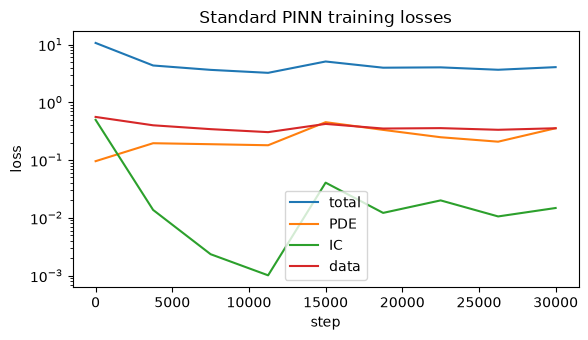

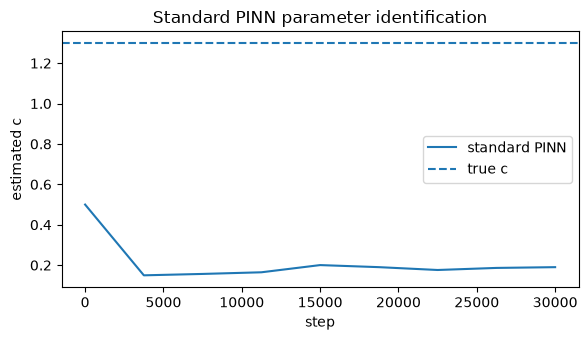


A. Standard PINN
----------------
relative L2 error: 1.1337 -> poor: the high-frequency solution is not learned well.
c_est: 0.190104, c_true: 1.300000, |error|=1.1099 -> poor: c is not reliably identified.
boundary MSE: 7.911e-03
held-out PDE residual MSE: 2.586e+01


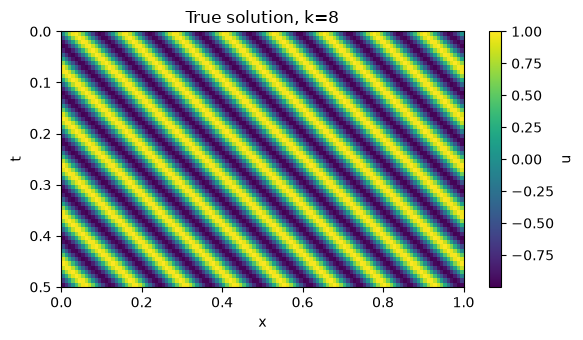

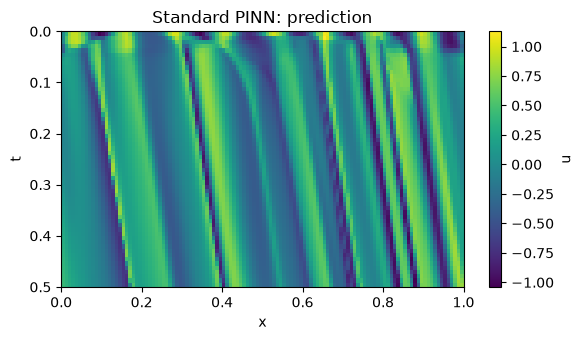

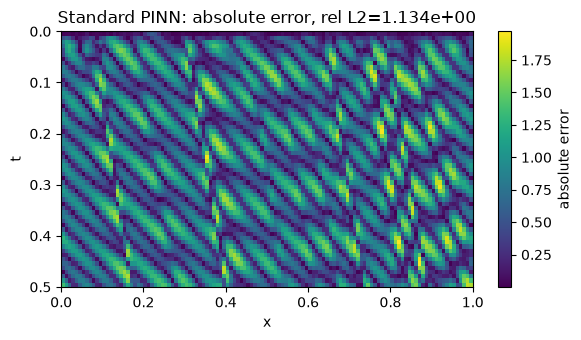

In [9]:
plt.figure(figsize=(6, 3.5))
plt.semilogy(std_h["step"], std_h["total"], label="total")
plt.semilogy(std_h["step"], std_h["pde"], label="PDE")
plt.semilogy(std_h["step"], std_h["ic"], label="IC")
plt.semilogy(std_h["step"], std_h["data"], label="data")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Standard PINN training losses")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(std_h["step"], std_h["c"], label="standard PINN")
plt.axhline(C_TRUE, linestyle="--", label="true c")
plt.xlabel("step")
plt.ylabel("estimated c")
plt.title("Standard PINN parameter identification")
plt.legend()
plt.tight_layout()
plt.show()

std_metrics = evaluate_on_grid(std_state, standard_apply)
print_interpretation("A. Standard PINN", std_metrics)
add_result(RESULTS, "A standard PINN", std_metrics)
plot_solution_comparison(std_metrics, "Standard PINN")

## 8. Diagnostic Analysis: Gradient Norm, Output NTK, and PDE Residual NTK

### 8.1 Gradient norm diagnosis

In a PINN, different loss terms may produce gradients with very different scales. Even if the numerical loss values look similar, the actual gradient driving the parameter update may be dominated by one particular term:

$$
\|\nabla_\theta L_{\mathrm{PDE}}\|,
\quad
\|\nabla_\theta L_{\mathrm{IC}}\|,
\quad
\|\nabla_\theta L_{\mathrm{BC}}\|,
\quad
\|\nabla_\theta L_{\mathrm{data}}\|.
$$

If the gradient of one term is much larger than the others, training may optimize only one constraint while ignoring the data or the initial condition.

Because this is an inverse problem, we also examine the sensitivity of each loss term with respect to $\tilde c$:

$$
\left|\frac{\partial L_j}{\partial \tilde c}\right|,
\qquad c=\operatorname{softplus}(\tilde c).
$$

All of these quantities are computed automatically using `jax.grad`. This part answers the question: **which loss term is actually driving the network parameters, and which loss term is driving the unknown parameter $c$?**


Standard PINN gradient norms:
  pde  : 9.724e+00
  ic   : 5.876e-01
  bc   : 9.773e-01
  data : 8.709e-01


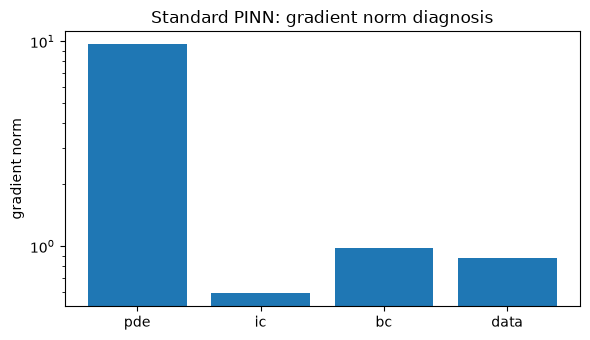


Standard PINN gradients with respect to raw_c, computed by full JAX autodiff:
  pde  : 2.738e-03
  ic   : 0.000e+00
  bc   : 0.000e+00
  data : 0.000e+00
  total: 2.738e-03


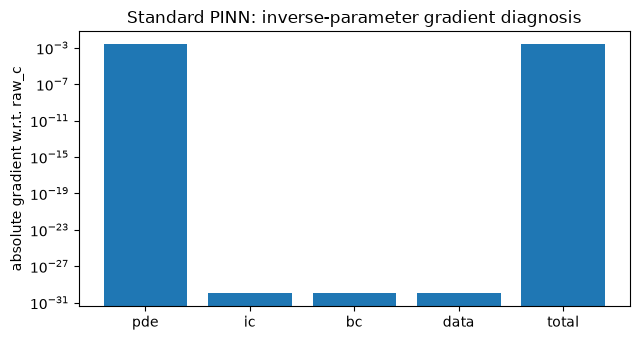

In [10]:
def gradient_norm_diagnosis(state, apply_fn, current_batch=batch):
    names = ["pde", "ic", "bc", "data"]
    norms = {}

    for name in names:
        def component_loss(params):
            temp_state = {"params": params, "raw_c": state["raw_c"]}
            return loss_parts(temp_state, current_batch, apply_fn)[name]

        g = jax.grad(component_loss)(state["params"])
        norms[name] = float(tree_l2_norm(g))

    return norms

std_norms = gradient_norm_diagnosis(std_state, standard_apply)
print("Standard PINN gradient norms:")
for k, v in std_norms.items():
    print(f"  {k:5s}: {v:.3e}")

labels = ["pde", "ic", "bc", "data"]
plt.figure(figsize=(6, 3.5))
plt.bar(labels, [std_norms[k] for k in labels])
plt.yscale("log")
plt.ylabel("gradient norm")
plt.title("Standard PINN: gradient norm diagnosis")
plt.tight_layout()
plt.show()

def inverse_parameter_gradient_diagnosis(state, apply_fn, current_batch=batch, weights=DEFAULT_WEIGHTS):
    """Full autodiff diagnosis for gradients with respect to raw_c.

    For each component L_j, this computes d L_j / d raw_c using jax.grad.
    Network parameters are held fixed.

    Important detail:
    loss_parts(...) returns only the unweighted components:
        pde, ic, bc, data
    It does NOT return "total". Therefore, for name == "total" we explicitly
    rebuild the weighted total loss using the supplied weights.
    """
    names = ["pde", "ic", "bc", "data", "total"]
    grads = {}

    for name in names:
        def component_loss(raw_c):
            temp_state = {"params": state["params"], "raw_c": raw_c}
            parts = loss_parts(temp_state, current_batch, apply_fn)
            if name == "total":
                return (
                    weights["pde"] * parts["pde"]
                    + weights["ic"] * parts["ic"]
                    + weights["bc"] * parts["bc"]
                    + weights["data"] * parts["data"]
                )
            return parts[name]

        g = jax.grad(component_loss)(state["raw_c"])
        grads[name] = float(jnp.abs(g))

    return grads

std_c_grads = inverse_parameter_gradient_diagnosis(std_state, standard_apply)
print("\nStandard PINN gradients with respect to raw_c, computed by full JAX autodiff:")
for k, v in std_c_grads.items():
    print(f"  {k:5s}: {v:.3e}")

labels_c = ["pde", "ic", "bc", "data", "total"]
plt.figure(figsize=(6.5, 3.5))
plt.bar(labels_c, [std_c_grads[k] + 1e-30 for k in labels_c])
plt.yscale("log")
plt.ylabel("absolute gradient w.r.t. raw_c")
plt.title("Standard PINN: inverse-parameter gradient diagnosis")
plt.tight_layout()
plt.show()


The gradient-norm plot shows which loss term dominates the update of the network parameters $\theta$; the inverse-gradient plot shows which loss term actually drives $\tilde c$. Therefore, we should not look only at loss values, because two loss terms with similar numerical values may have completely different effects on parameter updates.


### 8.2 Empirical output NTK

For the neural network $u_\theta$, the empirical output NTK at sampled points $z_i=(x_i,t_i)$ is defined as

$$
K^{(u)}_{ij}
=
\nabla_\theta u_\theta(z_i)^T
\nabla_\theta u_\theta(z_j).
$$

This kernel describes the local training dynamics of the network output $u_\theta$ around the current parameters. If the NTK eigenvalues decay very quickly, then some error directions are learned very slowly, and the training problem may be ill-conditioned.

In the code, `jax.jacrev` is used to compute the Jacobian with respect to the network parameters, and then we construct

$$K^{(u)}=J_uJ_u^T.$$


Computing full empirical output NTK on NTK_N=24 points.
If this cell crashes your kernel, reduce NTK_N or set RUN_NTK=False.
standard initial full NTK:
  largest eigenvalue: 3.627e+02
  smallest positive eigenvalue: 9.702e-06
  condition proxy: 3.739e+07
  effective rank: 1.16
standard trained full NTK:
  largest eigenvalue: 1.984e+04
  smallest positive eigenvalue: 3.322e-02
  condition proxy: 5.971e+05
  effective rank: 2.15


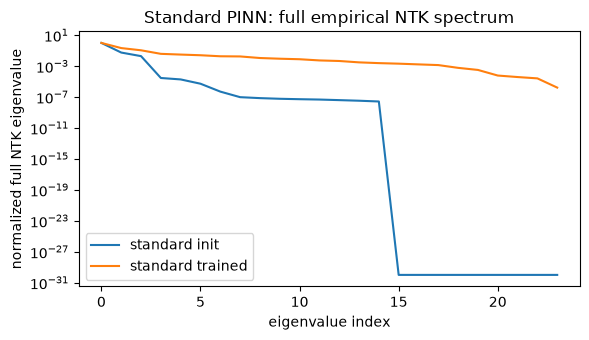

In [11]:
def compute_output_ntk_eigs(state, apply_fn, xt_sample):
    """Full empirical output NTK with respect to all network parameters.

    Given sample points X = {(x_i,t_i)}, define

        K_ij = grad_theta u_theta(x_i,t_i)^T grad_theta u_theta(x_j,t_j).

    This function flattens all MLP parameters, computes the full Jacobian
    J = d f_theta(X) / d theta, and returns the eigenvalues of K = J J^T.

    This is heavier than a last-layer proxy. Keep NTK_N small, for example
    8, 16, or 32, depending on your laptop.
    """
    flat_params, unravel = ravel_pytree(state["params"])

    def f_flat(theta_flat):
        params = unravel(theta_flat)
        return apply_fn(params, xt_sample)  # shape: (N,)

    J = jax.jacrev(f_flat)(flat_params)     # shape: (N, P)
    K = J @ J.T
    K = 0.5 * (K + K.T)
    eigs = jnp.linalg.eigvalsh(K)
    eigs = jnp.sort(jnp.maximum(eigs, 0.0))[::-1]
    return np.array(eigs)

def ntk_summary(eigs, name):
    eigs = np.maximum(eigs, 0.0)
    eigs = eigs[eigs > 1e-20]
    if len(eigs) == 0:
        print(name, "has no positive eigenvalues.")
        return {"largest": np.nan, "smallest": np.nan, "cond_proxy": np.nan, "eff_rank": np.nan}
    eff_rank = (np.sum(eigs)**2) / np.sum(eigs**2)
    cond_proxy = eigs[0] / eigs[-1]
    print(f"{name}:")
    print(f"  largest eigenvalue: {eigs[0]:.3e}")
    print(f"  smallest positive eigenvalue: {eigs[-1]:.3e}")
    print(f"  condition proxy: {cond_proxy:.3e}")
    print(f"  effective rank: {eff_rank:.2f}")
    return {"largest": eigs[0], "smallest": eigs[-1], "cond_proxy": cond_proxy, "eff_rank": eff_rank}

if RUN_NTK:
    xt_ntk = batch["xt_f"][:NTK_N]

    print(f"Computing full empirical output NTK on NTK_N={NTK_N} points.")
    print("If this cell crashes your kernel, reduce NTK_N or set RUN_NTK=False.")

    std_init_eigs = compute_output_ntk_eigs(std_init_state, standard_apply, xt_ntk)
    std_trained_eigs = compute_output_ntk_eigs(std_state, standard_apply, xt_ntk)

    _ = ntk_summary(std_init_eigs, "standard initial full NTK")
    _ = ntk_summary(std_trained_eigs, "standard trained full NTK")

    plt.figure(figsize=(6, 3.5))
    plt.semilogy(std_init_eigs / (std_init_eigs[0] + 1e-30) + 1e-30, label="standard init")
    plt.semilogy(std_trained_eigs / (std_trained_eigs[0] + 1e-30) + 1e-30, label="standard trained")
    plt.xlabel("eigenvalue index")
    plt.ylabel("normalized full NTK eigenvalue")
    plt.title("Standard PINN: full empirical NTK spectrum")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("NTK skipped. Set RUN_NTK=True to run this cell.")


The output NTK spectrum describes the local learning directions of $u_\theta$. Directions with large eigenvalues are easier to correct during training, while directions with small eigenvalues are learned slowly. If the spectrum decays quickly, it means that although the network can be trained, some error directions are very difficult to correct. This provides the diagnostic motivation for introducing Fourier features later.


### 8.3 PDE residual NTK: A more direct diagnostic for the physics loss

The output NTK looks at $u_\theta$, but the physics loss in a PINN actually constrains

$$r_\theta=u_t+c u_x.$$

Therefore, we can further define the PDE residual NTK:

$$
K^{(r)}_{ij}
=
\nabla_\theta r_\theta(z_i)^T
\nabla_\theta r_\theta(z_j).
$$

This kernel more directly describes the local learning directions of the PDE residual itself. Intuitively:

- the output NTK asks: which error directions of the network output $u_\theta$ are easy to learn?
- the residual NTK asks: which error directions of the PDE residual $r_\theta$ are easy to reduce?

In an inverse problem, the residual NTK is important because a decreasing PDE loss does not necessarily mean that $c$ is correct. Near a wrong value of $c$, the model may adjust $u_\theta$ so that the residual looks small.


Computing PDE residual NTK on RES_NTK_N=12 collocation points.
If this cell is too heavy, reduce RES_NTK_N to 6 or 8.
standard initial residual NTK, theta only:
  largest eigenvalue: 3.122e+02
  smallest positive eigenvalue: 3.174e-06
  condition proxy: 9.837e+07
  effective rank: 1.01
standard trained residual NTK, theta only:
  largest eigenvalue: 1.423e+06
  smallest positive eigenvalue: 1.957e+01
  condition proxy: 7.271e+04
  effective rank: 1.07
standard initial residual NTK, theta + raw_c:
  largest eigenvalue: 3.122e+02
  smallest positive eigenvalue: 9.382e-06
  condition proxy: 3.327e+07
  effective rank: 1.01
standard trained residual NTK, theta + raw_c:
  largest eigenvalue: 1.423e+06
  smallest positive eigenvalue: 1.958e+01
  condition proxy: 7.265e+04
  effective rank: 1.07


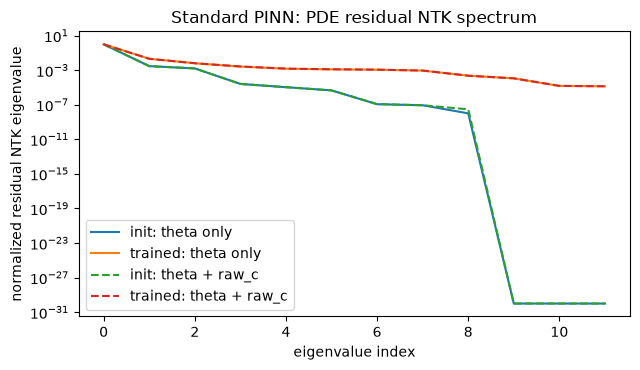


Interpretation guide:
- A steeper residual-NTK eigenvalue decay means the PDE residual has slow learning directions.
- If theta+raw_c differs strongly from theta-only, the inverse parameter c significantly changes residual dynamics.
- This does not by itself prove c is correct; it only diagnoses local trainability of the residual constraints.


In [12]:
def compute_residual_ntk_eigs(state, apply_fn, xt_sample, include_raw_c=False):
    """Empirical PDE residual NTK on collocation points.

    For residual values

        r_theta(X) = u_t(X) + c u_x(X),

    this computes the kernel

        K_r = J_r J_r^T,

    where J_r is the Jacobian of the residual vector with respect to the
    trainable variables.

    Parameters
    ----------
    include_raw_c : bool
        If False, J_r is taken only with respect to neural-network parameters theta.
        If True, J_r is taken with respect to [theta, raw_c].  This is useful for
        inverse problems because raw_c is also trained.

    Note
    ----
    This is more expensive than output NTK because residuals contain input
    derivatives u_x and u_t, so differentiating residuals with respect to theta
    involves mixed derivatives.  Keep RES_NTK_N small.
    """
    flat_params, unravel = ravel_pytree(state["params"])
    raw_c0 = jnp.asarray(state["raw_c"]).reshape(1)

    def residual_from_params(theta_flat):
        params = unravel(theta_flat)
        temp_state = {"params": params, "raw_c": state["raw_c"]}
        return pde_residual(temp_state, xt_sample, apply_fn)  # shape: (N,)

    if not include_raw_c:
        J = jax.jacrev(residual_from_params)(flat_params)    # shape: (N, P_theta)
    else:
        theta_size = flat_params.shape[0]
        augmented0 = jnp.concatenate([flat_params, raw_c0])

        def residual_from_augmented(augmented):
            theta_flat = augmented[:theta_size]
            raw_c = augmented[theta_size]
            params = unravel(theta_flat)
            temp_state = {"params": params, "raw_c": raw_c}
            return pde_residual(temp_state, xt_sample, apply_fn)  # shape: (N,)

        J = jax.jacrev(residual_from_augmented)(augmented0)  # shape: (N, P_theta + 1)

    K = J @ J.T
    K = 0.5 * (K + K.T)
    eigs = jnp.linalg.eigvalsh(K)
    eigs = jnp.sort(jnp.maximum(eigs, 0.0))[::-1]
    return np.array(eigs)

if RUN_NTK:
    RES_NTK_N = min(12, NTK_N)
    xt_res_ntk = batch["xt_f"][:RES_NTK_N]

    print(f"Computing PDE residual NTK on RES_NTK_N={RES_NTK_N} collocation points.")
    print("If this cell is too heavy, reduce RES_NTK_N to 6 or 8.")

    std_res_init_theta_eigs = compute_residual_ntk_eigs(
        std_init_state, standard_apply, xt_res_ntk, include_raw_c=False
    )
    std_res_trained_theta_eigs = compute_residual_ntk_eigs(
        std_state, standard_apply, xt_res_ntk, include_raw_c=False
    )

    std_res_init_aug_eigs = compute_residual_ntk_eigs(
        std_init_state, standard_apply, xt_res_ntk, include_raw_c=True
    )
    std_res_trained_aug_eigs = compute_residual_ntk_eigs(
        std_state, standard_apply, xt_res_ntk, include_raw_c=True
    )

    _ = ntk_summary(std_res_init_theta_eigs, "standard initial residual NTK, theta only")
    _ = ntk_summary(std_res_trained_theta_eigs, "standard trained residual NTK, theta only")
    _ = ntk_summary(std_res_init_aug_eigs, "standard initial residual NTK, theta + raw_c")
    _ = ntk_summary(std_res_trained_aug_eigs, "standard trained residual NTK, theta + raw_c")

    plt.figure(figsize=(6.5, 3.8))
    plt.semilogy(
        std_res_init_theta_eigs / (std_res_init_theta_eigs[0] + 1e-30) + 1e-30,
        label="init: theta only",
    )
    plt.semilogy(
        std_res_trained_theta_eigs / (std_res_trained_theta_eigs[0] + 1e-30) + 1e-30,
        label="trained: theta only",
    )
    plt.semilogy(
        std_res_init_aug_eigs / (std_res_init_aug_eigs[0] + 1e-30) + 1e-30,
        linestyle="--",
        label="init: theta + raw_c",
    )
    plt.semilogy(
        std_res_trained_aug_eigs / (std_res_trained_aug_eigs[0] + 1e-30) + 1e-30,
        linestyle="--",
        label="trained: theta + raw_c",
    )
    plt.xlabel("eigenvalue index")
    plt.ylabel("normalized residual NTK eigenvalue")
    plt.title("Standard PINN: PDE residual NTK spectrum")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nInterpretation:")
    print("- A steeper residual-NTK eigenvalue decay means the PDE residual has slow learning directions.")
    print("- If theta+raw_c differs strongly from theta-only, the inverse parameter c significantly changes residual dynamics.")
    print("- This does not by itself prove c is correct; it only diagnoses local trainability of the residual constraints.")
else:
    print("Residual NTK skipped because RUN_NTK=False.")


## 9. Representation Improvement: Fourier-Feature PINN

If the baseline does not reconstruct the high-frequency wave well, a natural suspicion is that an ordinary MLP cannot easily represent a high-frequency function. Therefore, this section introduces Fourier features, which first map the input into sine/cosine features.

This method mainly answers:

> Is the failure of the standard PINN mainly caused by insufficient high-frequency representation ability?

If Fourier features improve solution reconstruction or the NTK spectrum, but $c$ is still inaccurate, then representation ability is not the only bottleneck. In other words, Fourier features may help the network "draw the high-frequency wave", but they do not necessarily help the optimizer "find the correct wave speed."


In [13]:
try:
    jax.clear_caches()
except Exception:
    pass

fourier_state, fourier_hist, fourier_init_state = train_pinn(
    model_name="C Fourier-feature PINN",
    apply_fn=fourier_apply,
    input_dim=FOURIER_INPUT_DIM,
    seed=1,
    weights=DEFAULT_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
)

fourier_h = history_to_arrays(fourier_hist)

[C Fourier-feature PINN] step=    1 loss=1.299e+02 pde=1.18e+02 ic=5.55e-01 bc=7.70e-03 data=6.73e-01 c=0.500000
[C Fourier-feature PINN] step= 3750 loss=2.951e-01 pde=4.55e-03 ic=1.32e-03 bc=5.68e-03 data=2.72e-02 c=0.591134
[C Fourier-feature PINN] step= 7500 loss=4.741e-01 pde=4.35e-01 ic=5.89e-04 bc=1.58e-03 data=3.19e-03 c=0.635332
[C Fourier-feature PINN] step=11250 loss=2.561e-02 pde=1.18e-02 ic=1.80e-04 bc=6.89e-04 data=1.13e-03 c=0.633652
[C Fourier-feature PINN] step=15000 loss=9.113e-02 pde=8.33e-02 ic=1.65e-04 bc=4.36e-04 data=5.72e-04 c=0.622573
[C Fourier-feature PINN] step=18750 loss=1.529e-01 pde=1.48e-01 ic=9.68e-05 bc=3.01e-04 data=3.58e-04 c=0.609736
[C Fourier-feature PINN] step=22500 loss=2.584e-03 pde=4.45e-05 ic=5.76e-05 bc=2.02e-04 data=1.76e-04 c=0.594883
[C Fourier-feature PINN] step=26250 loss=2.722e-03 pde=9.58e-04 ic=4.29e-05 bc=1.40e-04 data=1.20e-04 c=0.578480
[C Fourier-feature PINN] step=30000 loss=4.526e-03 pde=3.21e-03 ic=3.43e-05 bc=1.00e-04 data=8.6

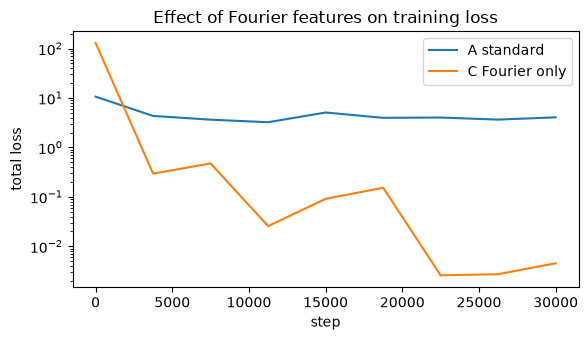

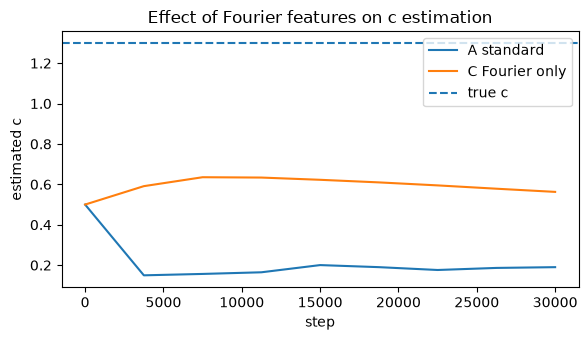


C. Fourier-feature PINN only
----------------------------
relative L2 error: 0.8135 -> poor: the high-frequency solution is not learned well.
c_est: 0.562763, c_true: 1.300000, |error|=0.7372 -> poor: c is not reliably identified.
boundary MSE: 5.480e-04
held-out PDE residual MSE: 7.267e+02


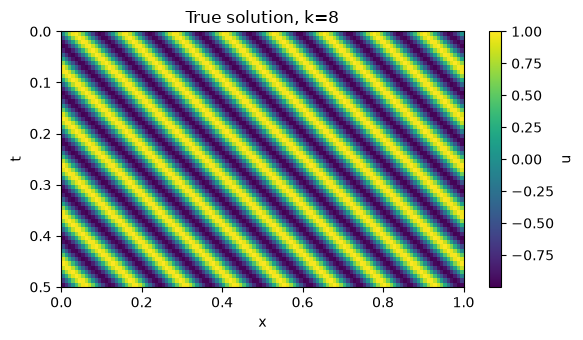

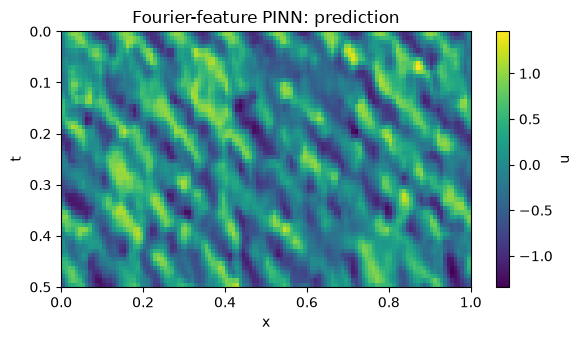

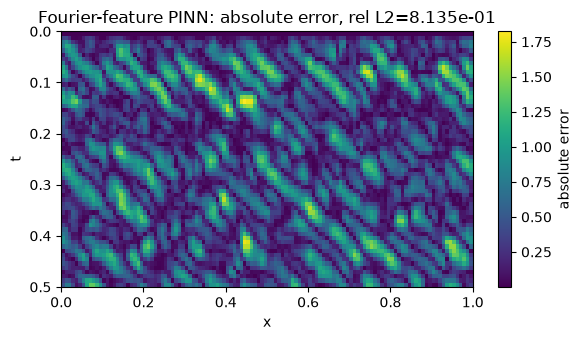

In [14]:
plt.figure(figsize=(6, 3.5))
plt.semilogy(std_h["step"], std_h["total"], label="A standard")
plt.semilogy(fourier_h["step"], fourier_h["total"], label="C Fourier only")
plt.xlabel("step")
plt.ylabel("total loss")
plt.title("Effect of Fourier features on training loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(std_h["step"], std_h["c"], label="A standard")
plt.plot(fourier_h["step"], fourier_h["c"], label="C Fourier only")
plt.axhline(C_TRUE, linestyle="--", label="true c")
plt.xlabel("step")
plt.ylabel("estimated c")
plt.title("Effect of Fourier features on c estimation")
plt.legend()
plt.tight_layout()
plt.show()

fourier_metrics = evaluate_on_grid(fourier_state, fourier_apply)
print_interpretation("C. Fourier-feature PINN only", fourier_metrics)
add_result(RESULTS, "C Fourier only", fourier_metrics, baseline=std_metrics)
plot_solution_comparison(fourier_metrics, "Fourier-feature PINN")

### 9.1 NTK Comparison Motivated by the Results: Standard vs Fourier

Here we compare the NTK spectra of the standard PINN and the Fourier-feature PINN.

> Fourier features change the input representation, which changes the network Jacobian at the sampled points and therefore changes the spectrum of the empirical NTK.

If the Fourier spectrum is flatter or has more effective eigenvalues, then it improves local training conditioning. However, if $c$ is still wrong, then inverse-parameter identification has an additional difficulty.


Fourier initial full NTK:
  largest eigenvalue: 2.300e+02
  smallest positive eigenvalue: 1.631e+00
  condition proxy: 1.410e+02
  effective rank: 9.29
Fourier trained full NTK:
  largest eigenvalue: 3.940e+02
  smallest positive eigenvalue: 1.733e+01
  condition proxy: 2.274e+01
  effective rank: 12.08


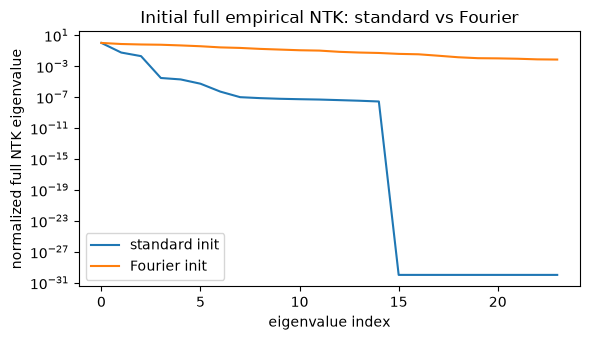

In [15]:
if RUN_NTK:
    fourier_init_eigs = compute_output_ntk_eigs(fourier_init_state, fourier_apply, xt_ntk)
    fourier_trained_eigs = compute_output_ntk_eigs(fourier_state, fourier_apply, xt_ntk)

    _ = ntk_summary(fourier_init_eigs, "Fourier initial full NTK")
    _ = ntk_summary(fourier_trained_eigs, "Fourier trained full NTK")

    plt.figure(figsize=(6, 3.5))
    plt.semilogy(std_init_eigs / (std_init_eigs[0] + 1e-30) + 1e-30, label="standard init")
    plt.semilogy(fourier_init_eigs / (fourier_init_eigs[0] + 1e-30) + 1e-30, label="Fourier init")
    plt.xlabel("eigenvalue index")
    plt.ylabel("normalized full NTK eigenvalue")
    plt.title("Initial full empirical NTK: standard vs Fourier")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("NTK skipped.")


## 10. Constraint Improvement: Hard Periodic Boundary Embedding

The solution of the advection equation is periodic in the $x$ direction. A soft-boundary PINN approximates the periodic boundary condition by penalizing

$$u_\theta(0,t)-u_\theta(1,t)$$

in the loss. Another approach is to directly build periodicity into the input features.

The hard-periodic embedding represents $x$ using

$$\sin(2\pi f_jx),\quad \cos(2\pi f_jx),$$

so the features at $x=0$ and $x=1$ are exactly identical. Therefore, the model satisfies the periodic boundary condition by construction.

This step mainly tests: **if the boundary condition is already structurally satisfied, can $c$ be learned correctly?** If the answer is no, then the main bottleneck is not the boundary condition, but the landscape of the inverse parameter.


In [16]:
try:
    jax.clear_caches()
except Exception:
    pass

hard_state, hard_hist, hard_init_state = train_pinn(
    model_name="D hard periodic boundary",
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    seed=2,
    weights=HARD_BC_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
)

hard_h = history_to_arrays(hard_hist)

[D hard periodic boundary] step=    1 loss=1.757e+02 pde=1.62e+02 ic=7.31e-01 bc=4.51e-13 data=6.10e-01 c=0.500000
[D hard periodic boundary] step= 3750 loss=3.599e-01 pde=8.27e-03 ic=2.02e-03 bc=8.10e-13 data=3.31e-02 c=0.569951
[D hard periodic boundary] step= 7500 loss=3.198e-01 pde=2.75e-01 ic=5.42e-04 bc=8.99e-13 data=3.99e-03 c=0.614581
[D hard periodic boundary] step=11250 loss=1.892e-02 pde=2.89e-03 ic=2.49e-04 bc=8.61e-13 data=1.35e-03 c=0.619525
[D hard periodic boundary] step=15000 loss=5.080e-02 pde=4.42e-02 ic=1.40e-04 bc=8.75e-13 data=5.21e-04 c=0.611885
[D hard periodic boundary] step=18750 loss=3.861e-03 pde=5.50e-04 ic=8.58e-05 bc=9.26e-13 data=2.45e-04 c=0.597403
[D hard periodic boundary] step=22500 loss=7.092e-03 pde=5.17e-03 ic=6.40e-05 bc=1.02e-12 data=1.28e-04 c=0.581693
[D hard periodic boundary] step=26250 loss=1.676e-03 pde=4.61e-04 ic=4.64e-05 bc=9.43e-13 data=7.52e-05 c=0.564507
[D hard periodic boundary] step=30000 loss=1.085e-01 pde=1.07e-01 ic=9.82e-05 bc

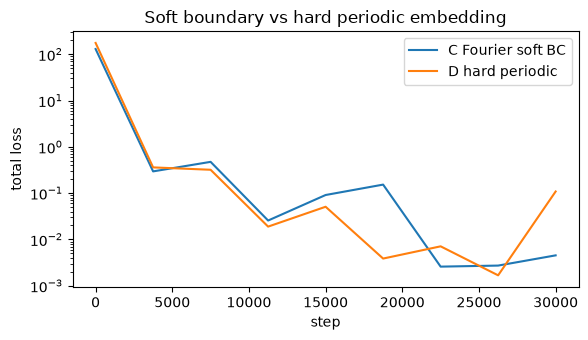

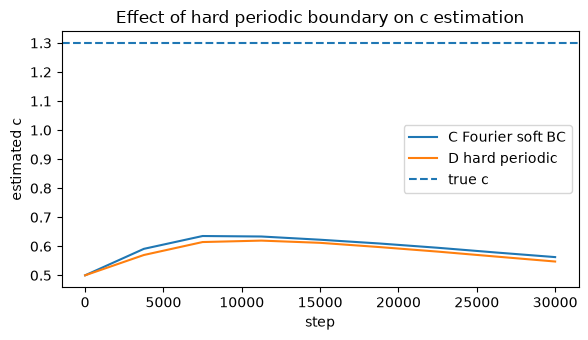


D. Hard periodic boundary
-------------------------
relative L2 error: 0.8314 -> poor: the high-frequency solution is not learned well.
c_est: 0.547508, c_true: 1.300000, |error|=0.7525 -> poor: c is not reliably identified.
boundary MSE: 1.032e-12
held-out PDE residual MSE: 5.824e+02


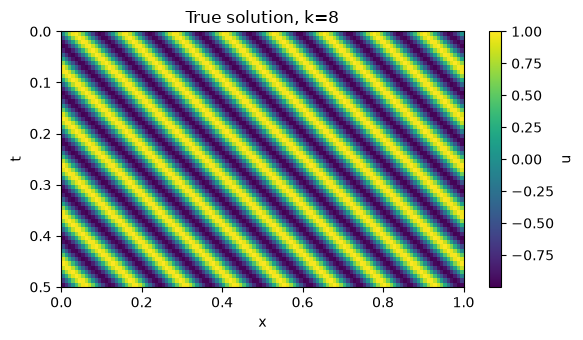

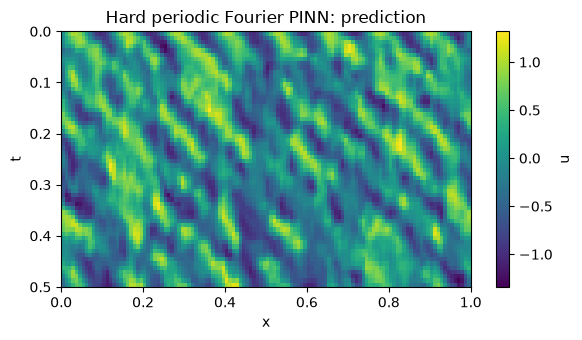

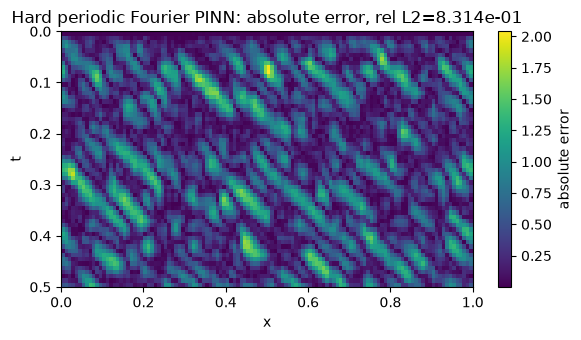

In [17]:
plt.figure(figsize=(6, 3.5))
plt.semilogy(fourier_h["step"], fourier_h["total"], label="C Fourier soft BC")
plt.semilogy(hard_h["step"], hard_h["total"], label="D hard periodic")
plt.xlabel("step")
plt.ylabel("total loss")
plt.title("Soft boundary vs hard periodic embedding")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 3.5))
plt.plot(fourier_h["step"], fourier_h["c"], label="C Fourier soft BC")
plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic")
plt.axhline(C_TRUE, linestyle="--", label="true c")
plt.xlabel("step")
plt.ylabel("estimated c")
plt.title("Effect of hard periodic boundary on c estimation")
plt.legend()
plt.tight_layout()
plt.show()

hard_metrics = evaluate_on_grid(hard_state, hard_periodic_apply)
print_interpretation("D. Hard periodic boundary", hard_metrics)
add_result(RESULTS, "D hard periodic", hard_metrics, baseline=fourier_metrics)
plot_solution_comparison(hard_metrics, "Hard periodic Fourier PINN")

## 11. Optimization Check: Giving the Inverse-Problem Parameter $c$ a Larger Learning Rate

If $c$ is not learned well, a simple suspicion is that the learning rate for $c$ is too small. Therefore, we increase $\eta_c$ and check whether $c$ can approach the true value faster.

> Is $c$ wrong because it updates too slowly, or because it is attracted to a wrong loss basin?

If increasing the learning rate for $c$ still cannot bring it close to $1.30$, or even makes training more unstable, then the problem is not merely that the step size is too small. It is more likely caused by the inverse-problem landscape or misleading early-stage residual gradients.


In [18]:
try:
    jax.clear_caches()
except Exception:
    pass

hard_fastc_state, hard_fastc_hist, hard_fastc_init_state = train_pinn(
    model_name="E hard periodic + faster c",
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    seed=2,  # same seed as D for fairer comparison
    weights=HARD_BC_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=3e-3,
)

hard_fastc_h = history_to_arrays(hard_fastc_hist)

[E hard periodic + faster c] step=    1 loss=1.757e+02 pde=1.62e+02 ic=7.31e-01 bc=4.51e-13 data=6.10e-01 c=0.500000
[E hard periodic + faster c] step= 3750 loss=3.932e-01 pde=8.61e-03 ic=1.90e-03 bc=1.17e-12 data=3.66e-02 c=0.511737
[E hard periodic + faster c] step= 7500 loss=1.487e-01 pde=1.01e-01 ic=5.04e-04 bc=1.69e-12 data=4.24e-03 c=0.553385
[E hard periodic + faster c] step=11250 loss=5.296e-02 pde=3.78e-02 ic=2.13e-04 bc=1.89e-12 data=1.30e-03 c=0.552784
[E hard periodic + faster c] step=15000 loss=8.992e-03 pde=2.21e-03 ic=1.24e-04 bc=1.87e-12 data=5.54e-04 c=0.539261
[E hard periodic + faster c] step=18750 loss=3.658e-03 pde=7.41e-05 ic=8.54e-05 bc=1.98e-12 data=2.73e-04 c=0.522567
[E hard periodic + faster c] step=22500 loss=6.762e-03 pde=4.52e-03 ic=6.44e-05 bc=1.97e-12 data=1.60e-04 c=0.504190
[E hard periodic + faster c] step=26250 loss=3.298e-03 pde=1.78e-03 ic=4.84e-05 bc=2.13e-12 data=1.04e-04 c=0.485286
[E hard periodic + faster c] step=30000 loss=2.260e-03 pde=1.07e

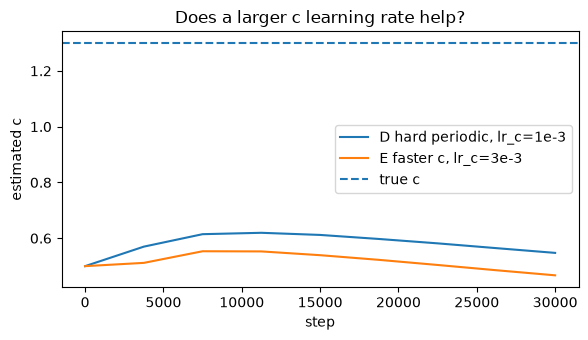


E. Hard periodic + faster c
---------------------------
relative L2 error: 0.9046 -> poor: the high-frequency solution is not learned well.
c_est: 0.467090, c_true: 1.300000, |error|=0.8329 -> poor: c is not reliably identified.
boundary MSE: 2.204e-12
held-out PDE residual MSE: 6.015e+02


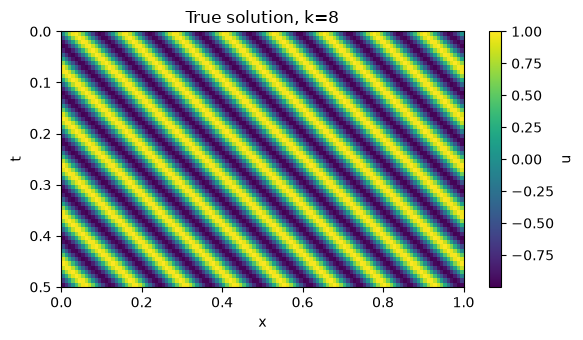

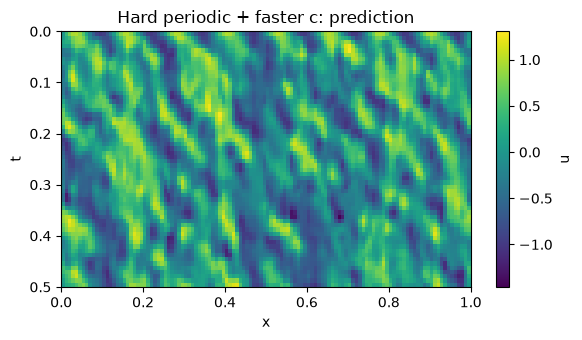

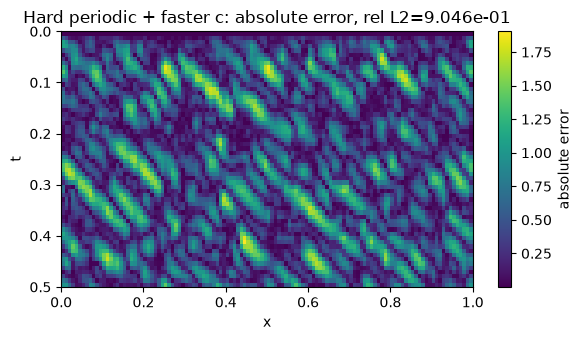

In [19]:
plt.figure(figsize=(6, 3.5))
plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic, lr_c=1e-3")
plt.plot(hard_fastc_h["step"], hard_fastc_h["c"], label="E faster c, lr_c=3e-3")
plt.axhline(C_TRUE, linestyle="--", label="true c")
plt.xlabel("step")
plt.ylabel("estimated c")
plt.title("Does a larger c learning rate help?")
plt.legend()
plt.tight_layout()
plt.show()

hard_fastc_metrics = evaluate_on_grid(hard_fastc_state, hard_periodic_apply)
print_interpretation("E. Hard periodic + faster c", hard_fastc_metrics)
add_result(RESULTS, "E hard periodic + faster c", hard_fastc_metrics, baseline=hard_metrics)
plot_solution_comparison(hard_fastc_metrics, "Hard periodic + faster c")

## 12. Inverse-Problem Landscape Analysis: Characteristic Baseline

To temporarily remove the neural-network factor, this section analyzes only $c$ itself. The characteristic formula for the advection equation gives

$$u(x,t;c)=u_0(x-ct).$$

Therefore, we can define a characteristic loss that depends only on $c$:

$$
L_{\mathrm{char}}(c)
=
\frac1N\sum_i
\left|
\sin(2\pi k(x_i-c t_i))-u_i
\right|^2.
$$

The meaning of this experiment is that even without training a neural network, the loss landscape of $c$ alone may contain multiple local basins. The reason is the phase periodicity of the high-frequency sine function: some wrong values of $c$ may still produce apparently similar phases at sparse observation points.

Therefore, the difficulty of $c$ is not a numerical bug unique to PINNs; it is an inherent phase ambiguity in this high-frequency inverse problem.


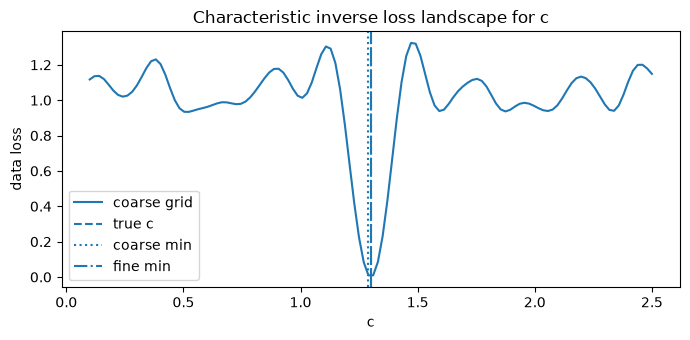

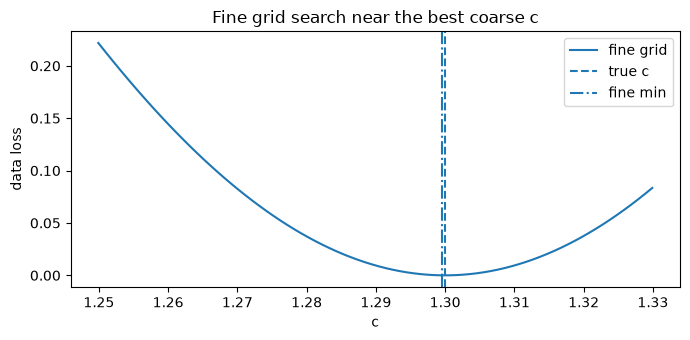

Grid-search minimum:
  c_coarse_min = 1.2899160385131836
  c_fine_min   = 1.2995362281799316
  fine loss    = 2.024137575062923e-05
  true c       = 1.3
  |c_init-c_true| = 0.0004637718200684038


In [20]:
try:
    jax.clear_caches()
except Exception:
    pass

def characteristic_predict(c, xt):
    x = xt[:, 0]
    t = xt[:, 1]
    return jnp.sin(2.0 * jnp.pi * K_FREQ * (x - c * t))

def characteristic_loss(c):
    pred = characteristic_predict(c, batch["xt_data"])
    return jnp.mean((pred - batch["y_data"])**2)

# First, a coarse grid over a wide range.
c_grid_coarse = jnp.linspace(C_GRID_MIN, C_GRID_MAX, C_GRID_COARSE_N)
loss_grid_coarse = jax.vmap(characteristic_loss)(c_grid_coarse)
idx_coarse = int(jnp.argmin(loss_grid_coarse))
c_coarse_min = float(c_grid_coarse[idx_coarse])

# Then, a fine grid around the best coarse value.
fine_left = max(C_GRID_MIN, c_coarse_min - C_GRID_FINE_RADIUS)
fine_right = min(C_GRID_MAX, c_coarse_min + C_GRID_FINE_RADIUS)
c_grid_fine = jnp.linspace(fine_left, fine_right, C_GRID_FINE_N)
loss_grid_fine = jax.vmap(characteristic_loss)(c_grid_fine)
idx_fine = int(jnp.argmin(loss_grid_fine))
c_fine_min = float(c_grid_fine[idx_fine])

plt.figure(figsize=(7, 3.5))
plt.plot(np.array(c_grid_coarse), np.array(loss_grid_coarse), label="coarse grid")
plt.axvline(C_TRUE, linestyle="--", label="true c")
plt.axvline(c_coarse_min, linestyle=":", label="coarse min")
plt.axvline(c_fine_min, linestyle="-.", label="fine min")
plt.xlabel("c")
plt.ylabel("data loss")
plt.title("Characteristic inverse loss landscape for c")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 3.5))
plt.plot(np.array(c_grid_fine), np.array(loss_grid_fine), label="fine grid")
plt.axvline(C_TRUE, linestyle="--", label="true c")
plt.axvline(c_fine_min, linestyle="-.", label="fine min")
plt.xlabel("c")
plt.ylabel("data loss")
plt.title("Fine grid search near the best coarse c")
plt.legend()
plt.tight_layout()
plt.show()

c_grid_init = c_fine_min
print("Grid-search minimum:")
print("  c_coarse_min =", c_coarse_min)
print("  c_fine_min   =", c_grid_init)
print("  fine loss    =", float(loss_grid_fine[idx_fine]))
print("  true c       =", C_TRUE)
print("  |c_init-c_true| =", abs(c_grid_init - C_TRUE))


Here we first remove the neural network and change only $c$. Since the data come from a high-frequency sine wave, different values of $c$ may produce similar phases at sparse points, so the loss may have multiple valleys. If joint training starts directly from $c_0=0.5$, the optimizer is likely to enter a wrong basin. This is the motivation for grid initialization in the next section.


### 12.1 From the Landscape to an Inverse-Specific Method

The characteristic landscape tells us that if the one-dimensional loss in $c$ is already nonconvex, then directly training $c$ together with the network parameters is likely to fail.

Therefore, the next step should not be merely increasing the number of training iterations. Instead, we should start $c$ from a more reasonable position. In other words, we need an initialization method designed specifically for the inverse-problem parameter, rather than relying only on random PINN initialization.


## 13. Main Method: Grid-Initialized Two-Stage Training

If the characteristic loss in $c$ is nonconvex, then starting from an arbitrary initial value such as $c_0=0.5$ and directly performing joint training can easily enter a wrong basin. Therefore, this section uses a two-step strategy.

### Step 1: Use grid search to initialize $c$

First, search the characteristic loss on a one-dimensional $c$-grid:

$$c_0=\arg\min_c L_{\mathrm{char}}(c).$$

This step does not train the neural network. It only uses the characteristic-line structure of the advection equation to find a better initial value for the parameter.

### Step 2: Two-stage PINN training

Even if $c_0$ is good, we should not allow $c$ and the network to make large joint updates from the very beginning. During early training, $u_\theta$ is still poor, so the PDE residual

$$r_\theta=u_t+c u_x$$

may provide misleading gradients for $c$. Therefore, we use two-stage training:

**Stage 1: Fix $c=c_0$ and train only the network parameters**

$$
\min_\theta
\left(
\lambda_f L_{\mathrm{PDE}}(\theta,c_0)
+\lambda_i L_{\mathrm{IC}}(\theta)
+\lambda_d L_{\mathrm{data}}(\theta)
\right).
$$

**Stage 2: Unfreeze $c$ and fine-tune it with a smaller learning rate**

$$
\min_{\theta,c}
\left(
\lambda_f L_{\mathrm{PDE}}(\theta,c)
+\lambda_i L_{\mathrm{IC}}(\theta)
+\lambda_d L_{\mathrm{data}}(\theta)
\right).
$$

The key judgment in this section is: if grid-initialized two-stage training clearly reduces $|c-c^*|$, then inverse-parameter initialization is a critical factor.


In [21]:
try:
    jax.clear_caches()
except Exception:
    pass

def train_pinn_freeze_c(
    model_name,
    apply_fn,
    input_dim,
    seed,
    c_init,
    weights=HARD_BC_WEIGHTS,
    n_steps=GRID_STAGE1_STEPS,
    lr_params=GRID_STAGE1_LR_PARAMS,
    current_batch=batch,
):
    """Train only network parameters while keeping raw_c fixed.

    This is useful for inverse problems: the network first learns a reasonable
    solution representation before the inverse parameter c is allowed to move.
    """
    state, opt_state = init_state_and_optimizer(input_dim, seed, c_init=c_init)
    opt_params = opt_state["params"]
    loss_fn = make_loss_fn(apply_fn, weights)

    @jax.jit
    def train_step_params_only(state, opt_params, current_batch):
        def loss_on_params(params):
            temp_state = {"params": params, "raw_c": state["raw_c"]}
            return loss_fn(temp_state, current_batch)

        (loss_value, parts), grad_params = jax.value_and_grad(
            loss_on_params, has_aux=True
        )(state["params"])

        new_params, new_opt_params = adam_update(
            state["params"], grad_params, opt_params, lr_params
        )
        new_state = {"params": new_params, "raw_c": state["raw_c"]}
        return new_state, new_opt_params, loss_value, parts

    history = []
    start = time.time()
    for step in range(1, n_steps + 1):
        state, opt_params, loss_value, parts = train_step_params_only(
            state, opt_params, current_batch
        )

        if step == 1 or step % PRINT_EVERY == 0 or step == n_steps:
            rec = {
                "step": step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] stage1 step={step:5d} "
                f"loss={rec['total']:.3e} pde={rec['pde']:.2e} "
                f"ic={rec['ic']:.2e} data={rec['data']:.2e} "
                f"c(fixed)={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] stage 1 finished in {elapsed:.1f} seconds.")
    return state, history

def continue_train_pinn(
    model_name,
    state,
    apply_fn,
    weights=HARD_BC_WEIGHTS,
    n_steps=GRID_STAGE2_STEPS,
    lr_params=GRID_STAGE2_LR_PARAMS,
    lr_c=GRID_STAGE2_LR_C,
    current_batch=batch,
    step_offset=0,
):
    """Continue training from an existing state, updating both theta and c."""
    opt_state = {"params": adam_init(state["params"]), "raw_c": adam_init(state["raw_c"])}
    loss_fn = make_loss_fn(apply_fn, weights)
    train_step = make_train_step(loss_fn, lr_params, lr_c)

    history = []
    start = time.time()
    for local_step in range(1, n_steps + 1):
        state, opt_state, loss_value, parts = train_step(state, opt_state, current_batch)
        global_step = step_offset + local_step

        if local_step == 1 or local_step % PRINT_EVERY == 0 or local_step == n_steps:
            rec = {
                "step": global_step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] stage2 step={global_step:5d} "
                f"loss={rec['total']:.3e} pde={rec['pde']:.2e} "
                f"ic={rec['ic']:.2e} data={rec['data']:.2e} "
                f"c={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] stage 2 finished in {elapsed:.1f} seconds.")
    return state, history

if RUN_GRID_INIT_PINN:
    print("Using grid-search initialization for two-stage PINN:")
    print("  c_init from characteristic coarse/fine grid =", c_grid_init)
    print("  true c =", C_TRUE)
    print("  stage 1 steps:", GRID_STAGE1_STEPS, "fixed c")
    print("  stage 2 steps:", GRID_STAGE2_STEPS, "lr_c =", GRID_STAGE2_LR_C)

    grid_stage1_state, grid_stage1_hist = train_pinn_freeze_c(
        model_name="I grid-initialized hard-periodic PINN",
        apply_fn=hard_periodic_apply,
        input_dim=HARD_PERIODIC_INPUT_DIM,
        seed=2,
        c_init=c_grid_init,
        weights=HARD_BC_WEIGHTS,
        n_steps=GRID_STAGE1_STEPS,
        lr_params=GRID_STAGE1_LR_PARAMS,
    )

    grid_init_state, grid_stage2_hist = continue_train_pinn(
        model_name="I grid-initialized hard-periodic PINN",
        state=grid_stage1_state,
        apply_fn=hard_periodic_apply,
        weights=HARD_BC_WEIGHTS,
        n_steps=GRID_STAGE2_STEPS,
        lr_params=GRID_STAGE2_LR_PARAMS,
        lr_c=GRID_STAGE2_LR_C,
        current_batch=batch,
        step_offset=GRID_STAGE1_STEPS,
    )

    grid_init_hist = grid_stage1_hist + grid_stage2_hist
    grid_init_h = history_to_arrays(grid_init_hist)
else:
    print("Grid-initialized PINN skipped. Set RUN_GRID_INIT_PINN=True to run this part.")

Using grid-search initialization for two-stage PINN:
  c_init from characteristic coarse/fine grid = 1.2995362281799316
  true c = 1.3
  stage 1 steps: 21000 fixed c
  stage 2 steps: 9000 lr_c = 0.0002
[I grid-initialized hard-periodic PINN] stage1 step=    1 loss=3.665e+02 pde=3.53e+02 ic=7.31e-01 data=6.10e-01 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step= 3750 loss=2.305e+00 pde=2.24e+00 ic=9.23e-04 data=5.60e-03 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step= 7500 loss=1.372e-02 pde=7.52e-04 ic=2.13e-04 data=1.08e-03 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step=11250 loss=1.022e-02 pde=4.11e-03 ic=9.91e-05 data=5.12e-04 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step=15000 loss=1.197e-01 pde=1.15e-01 ic=9.38e-05 data=3.75e-04 c(fixed)=1.299536
[I grid-initialized hard-periodic PINN] stage1 step=18750 loss=2.418e-03 pde=7.04e-05 ic=4.07e-05 data=1.94e-04 c(fixed)=1.299536
[I grid-initialize

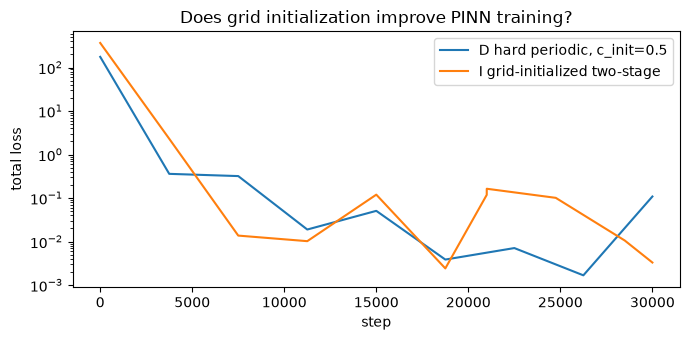

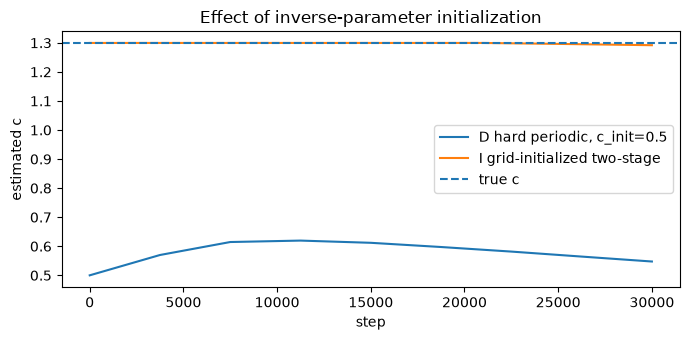


I. Grid-initialized two-stage hard-periodic PINN
------------------------------------------------
relative L2 error: 0.1186 -> good: the solution is learned reasonably well.
c_est: 1.291780, c_true: 1.300000, |error|=0.0082 -> good: c is accurately identified.
boundary MSE: 1.008e-12
held-out PDE residual MSE: 5.804e+01


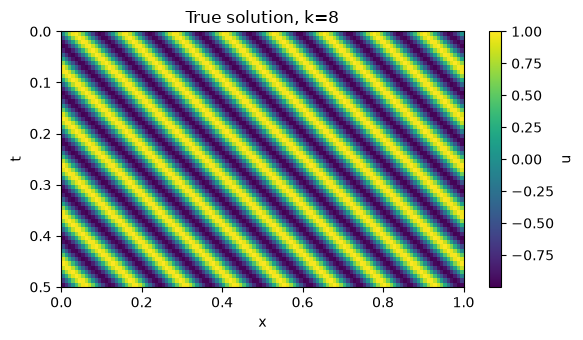

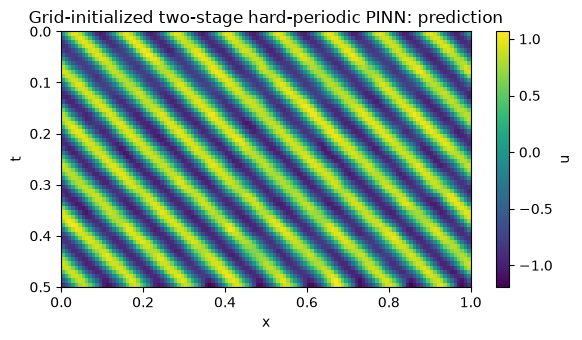

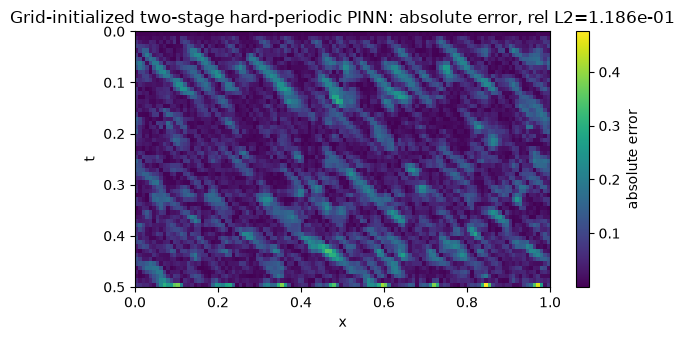

In [22]:
if RUN_GRID_INIT_PINN:
    plt.figure(figsize=(7, 3.5))
    plt.semilogy(hard_h["step"], hard_h["total"], label="D hard periodic, c_init=0.5")
    plt.semilogy(grid_init_h["step"], grid_init_h["total"], label="I grid-initialized two-stage")
    plt.xlabel("step")
    plt.ylabel("total loss")
    plt.title("Does grid initialization improve PINN training?")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic, c_init=0.5")
    plt.plot(grid_init_h["step"], grid_init_h["c"], label="I grid-initialized two-stage")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Effect of inverse-parameter initialization")
    plt.legend()
    plt.tight_layout()
    plt.show()

    grid_init_metrics = evaluate_on_grid(grid_init_state, hard_periodic_apply)
    print_interpretation("I. Grid-initialized two-stage hard-periodic PINN", grid_init_metrics)
    add_result(RESULTS, "I grid-init two-stage", grid_init_metrics, baseline=hard_metrics)
    plot_solution_comparison(grid_init_metrics, "Grid-initialized two-stage hard-periodic PINN")


This method is inverse-specific: it first uses the characteristic formula to place $c$ near a reasonable basin, then fixes $c$ while training the network, and only finally fine-tunes $c$. It separates "fitting the solution field" from "identifying the parameter", avoiding wrong gradients for $c$ from an inaccurate early-stage $u_\theta$.


## 14. Additional Methods After Grid Initialization: Can We Recover $c$ Without Grid Search?

The grid-initialized two-stage method works because it first places $c$ in a good basin. However, many inverse-PINN papers do not explicitly perform a one-dimensional grid search for the unknown coefficient. They usually rely on joint training, data pretraining, stronger observation loss, adaptive weighting, or alternating optimization.

Therefore, after the main grid-initialized method, we add four extra attempts. Their purpose is not to replace the grid method immediately, but to diagnose **why ordinary joint PINN training cannot move $c$ to the correct value**.

### 14.1 Method A: Data-guided pretraining, then update $c$

In the current model,

$$u_\theta=u_\theta(x,t),\qquad r_\theta=u_t+c u_x.$$

The data loss

$$L_{\mathrm{data}}=\|u_\theta(x_i,t_i)-u_i\|^2$$

does not directly depend on $c$. Hence, early in training, $c$ is mainly updated by the PDE residual, but $u_\theta$ may still have inaccurate derivatives $u_t$ and $u_x$. This can give a misleading gradient for $c$.

So we first freeze $c$ and train only the neural network with data / IC / BC losses:

$$
L_{\mathrm{pre}}
=\lambda_d L_{\mathrm{data}}
+\lambda_i L_{\mathrm{IC}}
+\lambda_b L_{\mathrm{BC}}.
$$

Then we add the PDE loss and unfreeze $c$:

$$
L_{\mathrm{fine}}
=\lambda_f L_{\mathrm{PDE}}
+\lambda_d L_{\mathrm{data}}
+\lambda_i L_{\mathrm{IC}}
+\lambda_b L_{\mathrm{BC}}.
$$

If this helps, then the failure of ordinary joint training is partly caused by inaccurate early derivatives.

### 14.2 Method C: Alternating training

Instead of updating $u_\theta$ and $c$ simultaneously from the start, we alternate:

1. fix $c$ and train $u_\theta$;
2. fix $u_\theta$ and update $c$;
3. repeat.

When $u_\theta$ is fixed, the PDE residual is linear in $c$:

$$r=u_t+c u_x.$$

Therefore, minimizing

$$\sum_i (u_t+c u_x)^2$$

gives the least-squares update

$$
c_{\mathrm{LS}}
=-\frac{\sum_i u_t(x_i,t_i)u_x(x_i,t_i)}
{\sum_i u_x(x_i,t_i)^2}.
$$

This is not grid search. It uses the PDE residual itself to estimate $c$ after the network has learned a better approximation of the solution field.

### 14.3 Method E: Put $c$ directly into the data loss by a characteristic-informed ansatz

For the advection equation,

$$u_t+c u_x=0,$$

the characteristic formula is

$$u(x,t)=u_0(x-ct).$$

If the initial profile $u_0$ is known, we can define

$$u_c(x,t)=u_0(x-ct),$$

and minimize a direct data loss

$$
L_d(c)
=\|u_0(x_i-c t_i)-u_i\|^2.
$$

Now $c$ appears directly inside the data loss. This is no longer a generic PINN; it hard-codes the characteristic structure of the advection equation. But it is useful as a diagnostic: if this works while joint PINN fails, then the main issue is not the data itself, but the indirect way $c$ is learned in the generic PINN.

### 14.4 Method F: Loss curriculum

In ordinary joint training, the PDE residual may dominate too early. We therefore start with a weak PDE loss and gradually increase it:

$$
\lambda_f=0.01 \quad\rightarrow\quad 0.1 \quad\rightarrow\quad 1.
$$

The idea is to let data / IC / BC shape the solution field first, and only later enforce the PDE strongly. If this helps, the original failure is related to loss imbalance and early-stage residual gradients. If it still does not recover $c$, then the basin problem is more fundamental.


In [23]:
try:
    jax.clear_caches()
except Exception:
    pass

# Extra experiments after grid initialization.
RUN_DATA_GUIDED_PRETRAINING = True
RUN_ALTERNATING_LS_TRAINING = True
RUN_CHARACTERISTIC_DIRECT_GD = True
RUN_LOSS_CURRICULUM_EXPERIMENT = True
RUN_ADAPTIVE_GRAD_WEIGHTING = True
RUN_TRANSPORT_C_VISIBLE_PINN = True
RUN_RAR_EXPERIMENT = True   

# Method A settings
DATA_PRETRAIN_FRACTION = 0.50
DATA_PRETRAIN_STEPS = max(1, int(DATA_PRETRAIN_FRACTION * N_STEPS))
DATA_FINETUNE_STEPS = max(1, N_STEPS - DATA_PRETRAIN_STEPS)
DATA_GUIDED_PRE_WEIGHTS = {
    "pde": 0.0,
    "ic": 10.0,
    "bc": 0.0,    # hard-periodic model already enforces periodicity
    "data": 10.0,
}

# Method C settings
ALT_CYCLES = 4
ALT_THETA_STEPS = max(1, N_STEPS // (ALT_CYCLES + 1))
ALT_FINAL_FINE_STEPS = max(1, N_STEPS - ALT_CYCLES * ALT_THETA_STEPS)

# Method E settings
CHAR_DIRECT_STEPS = N_STEPS
CHAR_DIRECT_LR_C = 1e-2

# Method F settings
LOSS_CURR_STAGE1 = max(1, int(0.40 * N_STEPS))
LOSS_CURR_STAGE2 = max(1, int(0.30 * N_STEPS))
LOSS_CURR_STAGE3 = max(1, N_STEPS - LOSS_CURR_STAGE1 - LOSS_CURR_STAGE2)
LOSS_CURRICULUM_SCHEDULE = [
    ("weak PDE",   {"pde": 0.01, "ic": 10.0, "bc": 0.0, "data": 10.0}, LOSS_CURR_STAGE1),
    ("medium PDE", {"pde": 0.10, "ic": 10.0, "bc": 0.0, "data": 10.0}, LOSS_CURR_STAGE2),
    ("full PDE",   {"pde": 1.00, "ic": 10.0, "bc": 0.0, "data": 10.0}, LOSS_CURR_STAGE3),
]

# Method G settings: adaptive loss weighting by gradient-norm balancing.
# This is a lightweight approximation of adaptive loss-balancing ideas used in PINN papers.
ADAPTIVE_REWEIGHT_EVERY = max(1, N_STEPS // 4)
ADAPTIVE_WEIGHT_SMOOTHING = 0.80
ADAPTIVE_WEIGHT_EPS = 1e-12
ADAPTIVE_WEIGHT_CLIP = (0.05, 100.0)

# Method H settings: make c directly visible to the data loss through the input map.
# Instead of u_theta(x,t), use u_theta(x - c t, t, c).
TRANSPORT_C_VISIBLE_STEPS = N_STEPS
TRANSPORT_C_VISIBLE_LR_PARAMS = 1e-3
TRANSPORT_C_VISIBLE_LR_C = 1e-3
TRANSPORT_C_VISIBLE_WEIGHTS = {
    "pde": 1.0,
    "ic": 10.0,
    "bc": 0.0,    # the transport-coordinate features are periodic in x
    "data": 10.0,
}

# Method I settings: residual-based adaptive refinement (RAR).
RAR_PRETRAIN_STEPS = max(1, int(RAR_PRETRAIN_FRACTION * N_STEPS))
RAR_FINETUNE_STEPS = max(1, N_STEPS - RAR_PRETRAIN_STEPS)

def continue_train_params_only(
    model_name,
    state,
    apply_fn,
    weights,
    n_steps,
    lr_params=1e-3,
    current_batch=batch,
    step_offset=0,
):
    """Continue training only network parameters while keeping raw_c fixed."""
    opt_params = adam_init(state["params"])
    loss_fn = make_loss_fn(apply_fn, weights)

    @jax.jit
    def train_step_params_only_from_state(state, opt_params, current_batch):
        def loss_on_params(params):
            temp_state = {"params": params, "raw_c": state["raw_c"]}
            return loss_fn(temp_state, current_batch)

        (loss_value, parts), grad_params = jax.value_and_grad(
            loss_on_params, has_aux=True
        )(state["params"])

        new_params, new_opt_params = adam_update(
            state["params"], grad_params, opt_params, lr_params
        )
        new_state = {"params": new_params, "raw_c": state["raw_c"]}
        return new_state, new_opt_params, loss_value, parts

    history = []
    for local_step in range(1, n_steps + 1):
        state, opt_params, loss_value, parts = train_step_params_only_from_state(
            state, opt_params, current_batch
        )
        global_step = step_offset + local_step
        if local_step == 1 or local_step % PRINT_EVERY == 0 or local_step == n_steps:
            rec = {
                "step": global_step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] params-only step={global_step:5d} "
                f"loss={rec['total']:.3e} pde={rec['pde']:.2e} "
                f"ic={rec['ic']:.2e} data={rec['data']:.2e} "
                f"c(fixed)={rec['c']:.6f}"
            )
    return state, history

def derivative_components(state, xt, apply_fn):
    """Return u_t and u_x on sample points for the current network."""
    params = state["params"]

    def u_single(z):
        z = z.reshape(1, 2)
        return apply_fn(params, z)[0]

    grad_u = jax.vmap(jax.grad(u_single))(xt)
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    return u_t, u_x

def estimate_c_least_squares_from_state(
    state,
    apply_fn,
    xt=None,
    c_min=C_GRID_MIN,
    c_max=C_GRID_MAX,
):
    """Least-squares estimate of c from u_t + c u_x = 0 with fixed u_theta."""
    if xt is None:
        xt = batch["xt_f"]
    u_t, u_x = derivative_components(state, xt, apply_fn)
    numerator = jnp.sum(u_t * u_x)
    denominator = jnp.sum(u_x**2) + 1e-8
    c_ls = -numerator / denominator
    c_ls = jnp.clip(c_ls, c_min, c_max)
    return float(c_ls)

def set_state_c(state, c_value):
    return {"params": state["params"], "raw_c": inv_softplus(c_value)}

def record_current_state(step, state, apply_fn, weights, current_batch=batch):
    loss_fn = make_loss_fn(apply_fn, weights)
    _, parts = loss_fn(state, current_batch)
    return {
        "step": step,
        "total": float(parts["total"]),
        "pde": float(parts["pde"]),
        "ic": float(parts["ic"]),
        "bc": float(parts["bc"]),
        "data": float(parts["data"]),
        "c": float(parts["c"]),
    }



Method A: data-guided pretraining, then update c
  stage 1: train data / IC only with c fixed at 0.5
  stage 2: add PDE loss and update both theta and c
[J data-guided pretraining] params-only step=    1 loss=1.238e+01 pde=5.31e+02 ic=5.75e-01 data=6.63e-01 c(fixed)=0.500000
[J data-guided pretraining] params-only step= 3750 loss=3.267e-05 pde=1.13e+03 ic=3.14e-06 data=1.29e-07 c(fixed)=0.500000
[J data-guided pretraining] params-only step= 7500 loss=1.437e-05 pde=1.07e+03 ic=1.42e-06 data=1.36e-08 c(fixed)=0.500000
[J data-guided pretraining] params-only step=11250 loss=1.008e-05 pde=1.04e+03 ic=9.62e-07 data=4.60e-08 c(fixed)=0.500000
[J data-guided pretraining] params-only step=15000 loss=1.451e-03 pde=1.03e+03 ic=2.77e-05 data=1.17e-04 c(fixed)=0.500000
[J data-guided fine-tuning] stage2 step=15001 loss=1.024e+03 pde=1.02e+03 ic=3.75e-05 data=1.38e-04 c=0.500000
[J data-guided fine-tuning] stage2 step=18750 loss=8.675e-02 pde=2.18e-03 ic=6.57e-04 data=7.80e-03 c=0.575808
[J data-g

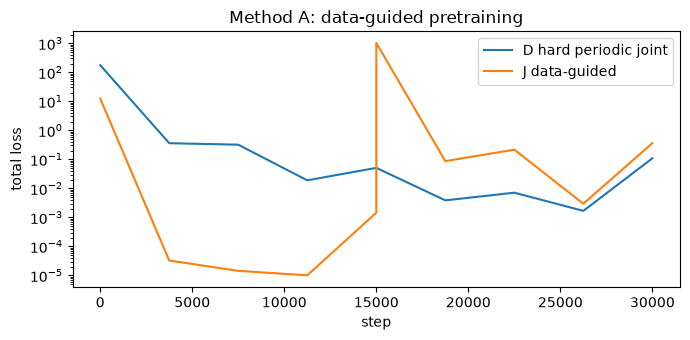

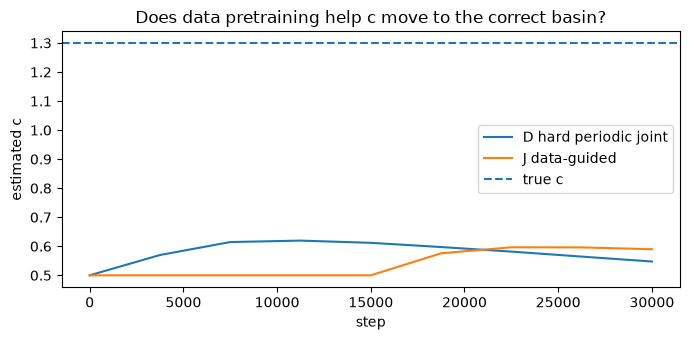


J. Data-guided pretraining + fine-tuning
----------------------------------------
relative L2 error: 0.7350 -> poor: the high-frequency solution is not learned well.
c_est: 0.589772, c_true: 1.300000, |error|=0.7102 -> poor: c is not reliably identified.
boundary MSE: 1.171e-12
held-out PDE residual MSE: 6.428e+02


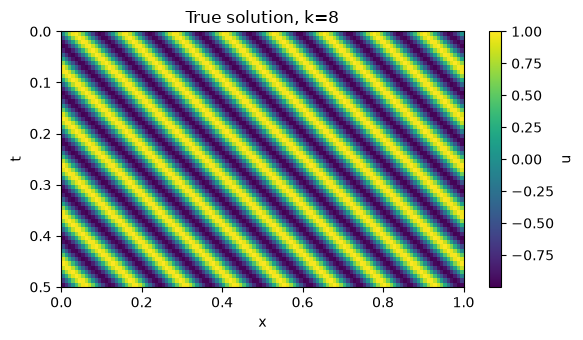

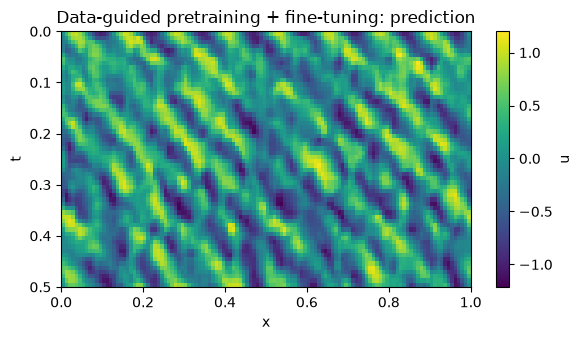

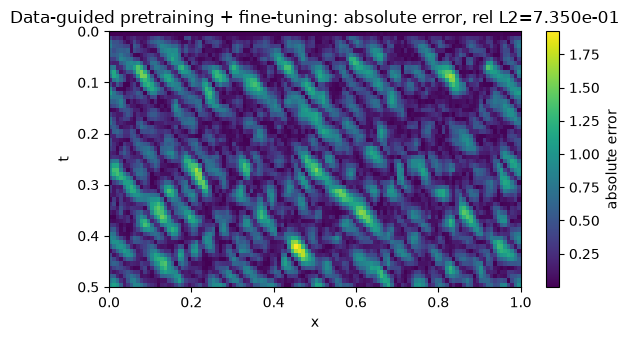

In [24]:
# Method A: data-guided pretraining, then unfreeze c.
if RUN_DATA_GUIDED_PRETRAINING:
    print("\nMethod A: data-guided pretraining, then update c")
    print("  stage 1: train data / IC only with c fixed at 0.5")
    print("  stage 2: add PDE loss and update both theta and c")

    data_guided_state0, _ = init_state_and_optimizer(
        HARD_PERIODIC_INPUT_DIM, seed=20, c_init=0.50
    )

    data_guided_stage1_state, data_guided_stage1_hist = continue_train_params_only(
        model_name="J data-guided pretraining",
        state=data_guided_state0,
        apply_fn=hard_periodic_apply,
        weights=DATA_GUIDED_PRE_WEIGHTS,
        n_steps=DATA_PRETRAIN_STEPS,
        lr_params=1e-3,
        current_batch=batch,
        step_offset=0,
    )

    data_guided_state, data_guided_stage2_hist = continue_train_pinn(
        model_name="J data-guided fine-tuning",
        state=data_guided_stage1_state,
        apply_fn=hard_periodic_apply,
        weights=HARD_BC_WEIGHTS,
        n_steps=DATA_FINETUNE_STEPS,
        lr_params=1e-3,
        lr_c=1e-3,
        current_batch=batch,
        step_offset=DATA_PRETRAIN_STEPS,
    )

    data_guided_hist = data_guided_stage1_hist + data_guided_stage2_hist
    data_guided_h = history_to_arrays(data_guided_hist)

    plt.figure(figsize=(7, 3.5))
    plt.semilogy(hard_h["step"], hard_h["total"], label="D hard periodic joint")
    plt.semilogy(data_guided_h["step"], data_guided_h["total"], label="J data-guided")
    plt.xlabel("step")
    plt.ylabel("total loss")
    plt.title("Method A: data-guided pretraining")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(data_guided_h["step"], data_guided_h["c"], label="J data-guided")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Does data pretraining help c move to the correct basin?")
    plt.legend()
    plt.tight_layout()
    plt.show()

    data_guided_metrics = evaluate_on_grid(data_guided_state, hard_periodic_apply)
    print_interpretation("J. Data-guided pretraining + fine-tuning", data_guided_metrics)
    add_result(RESULTS, "J data-guided", data_guided_metrics, baseline=hard_metrics)
    plot_solution_comparison(data_guided_metrics, "Data-guided pretraining + fine-tuning")
else:
    print("Method A skipped. Set RUN_DATA_GUIDED_PRETRAINING=True to run it.")



Method C: alternating training with PDE least-squares c update

[K alternating LS] alternating cycle 1/4
[K alternating LS cycle 1: train theta] params-only step=    1 loss=3.262e+02 pde=3.11e+02 ic=7.84e-01 data=7.37e-01 c(fixed)=0.500000
[K alternating LS cycle 1: train theta] params-only step= 3750 loss=1.228e+00 pde=8.29e-01 ic=1.76e-03 data=3.82e-02 c(fixed)=0.500000
[K alternating LS cycle 1: train theta] params-only step= 6000 loss=6.999e-02 pde=2.32e-03 ic=6.21e-04 data=6.15e-03 c(fixed)=0.500000
[K alternating LS] LS update c: 0.500000 -> 0.500093 at step 6000

[K alternating LS] alternating cycle 2/4
[K alternating LS cycle 2: train theta] params-only step= 6001 loss=6.847e-02 pde=8.11e-04 ic=6.19e-04 data=6.15e-03 c(fixed)=0.500093
[K alternating LS cycle 2: train theta] params-only step= 9750 loss=2.258e-02 pde=3.02e-03 ic=2.54e-04 data=1.70e-03 c(fixed)=0.500093
[K alternating LS cycle 2: train theta] params-only step=12000 loss=2.639e-02 pde=1.47e-02 ic=1.65e-04 data=1.0

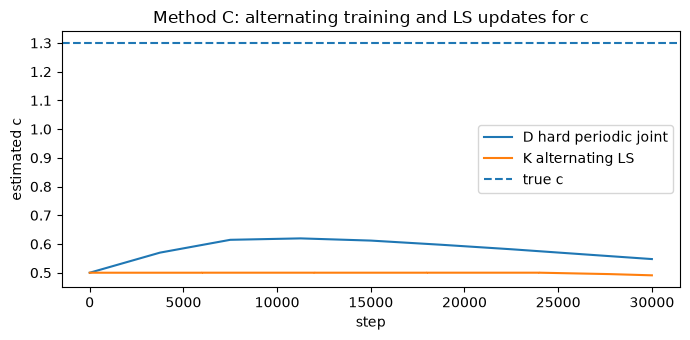


K. Alternating training with LS c update
----------------------------------------
relative L2 error: 0.8854 -> poor: the high-frequency solution is not learned well.
c_est: 0.490949, c_true: 1.300000, |error|=0.8091 -> poor: c is not reliably identified.
boundary MSE: 1.620e-12
held-out PDE residual MSE: 6.115e+02


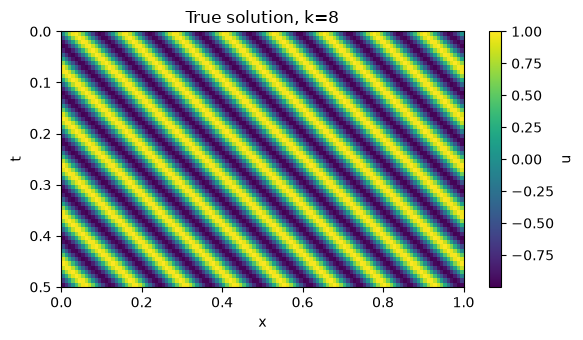

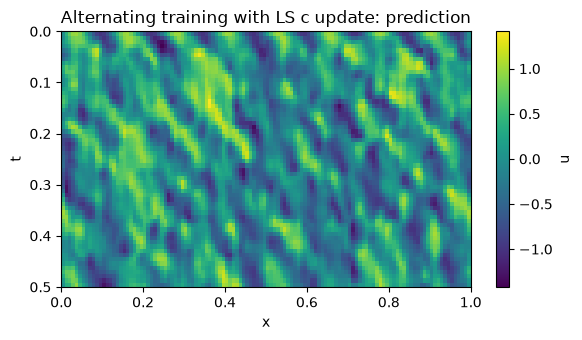

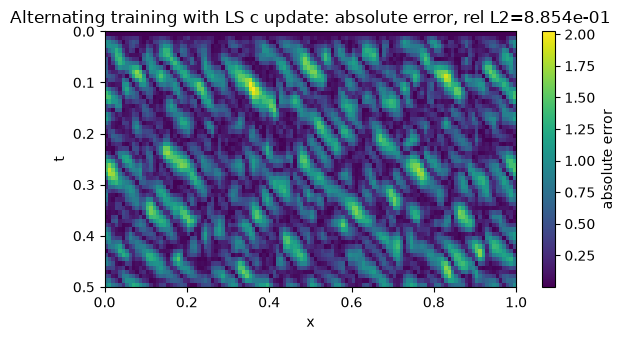

In [25]:
# Method C: alternating training with a least-squares update for c.
def train_alternating_ls(
    model_name,
    seed=21,
    c_init=0.50,
    cycles=ALT_CYCLES,
    theta_steps=ALT_THETA_STEPS,
    final_fine_steps=ALT_FINAL_FINE_STEPS,
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    weights=HARD_BC_WEIGHTS,
):
    state, _ = init_state_and_optimizer(input_dim, seed=seed, c_init=c_init)
    history = []
    global_step = 0

    for cycle in range(1, cycles + 1):
        print(f"\n[{model_name}] alternating cycle {cycle}/{cycles}")
        state, hist_theta = continue_train_params_only(
            model_name=f"{model_name} cycle {cycle}: train theta",
            state=state,
            apply_fn=apply_fn,
            weights=weights,
            n_steps=theta_steps,
            lr_params=1e-3,
            current_batch=batch,
            step_offset=global_step,
        )
        history.extend(hist_theta)
        global_step += theta_steps

        c_old = float(positive(state["raw_c"]))
        c_ls = estimate_c_least_squares_from_state(state, apply_fn, xt=batch["xt_f"])
        state = set_state_c(state, c_ls)
        rec = record_current_state(global_step, state, apply_fn, weights)
        history.append(rec)
        print(
            f"[{model_name}] LS update c: {c_old:.6f} -> {c_ls:.6f} "
            f"at step {global_step}"
        )

    if final_fine_steps > 0:
        state, hist_fine = continue_train_pinn(
            model_name=f"{model_name} final joint fine-tune",
            state=state,
            apply_fn=apply_fn,
            weights=weights,
            n_steps=final_fine_steps,
            lr_params=1e-3,
            lr_c=5e-4,
            current_batch=batch,
            step_offset=global_step,
        )
        history.extend(hist_fine)

    return state, history

if RUN_ALTERNATING_LS_TRAINING:
    print("\nMethod C: alternating training with PDE least-squares c update")
    alternating_state, alternating_hist = train_alternating_ls(
        model_name="K alternating LS"
    )
    alternating_h = history_to_arrays(alternating_hist)

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(alternating_h["step"], alternating_h["c"], label="K alternating LS")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Method C: alternating training and LS updates for c")
    plt.legend()
    plt.tight_layout()
    plt.show()

    alternating_metrics = evaluate_on_grid(alternating_state, hard_periodic_apply)
    print_interpretation("K. Alternating training with LS c update", alternating_metrics)
    add_result(RESULTS, "K alternating LS", alternating_metrics, baseline=hard_metrics)
    plot_solution_comparison(alternating_metrics, "Alternating training with LS c update")
else:
    print("Method C skipped. Set RUN_ALTERNATING_LS_TRAINING=True to run it.")



Method E: characteristic-informed direct data loss for c
[L characteristic-direct] step=    1 loss=9.361e-01 c=0.503947
[L characteristic-direct] step= 3750 loss=9.325e-01 c=0.513533
[L characteristic-direct] step= 7500 loss=9.325e-01 c=0.513531
[L characteristic-direct] step=11250 loss=9.325e-01 c=0.513522
[L characteristic-direct] step=15000 loss=9.325e-01 c=0.513507
[L characteristic-direct] step=18750 loss=9.325e-01 c=0.513367
[L characteristic-direct] step=22500 loss=9.325e-01 c=0.513446
[L characteristic-direct] step=26250 loss=9.325e-01 c=0.513611
[L characteristic-direct] step=30000 loss=9.325e-01 c=0.513533


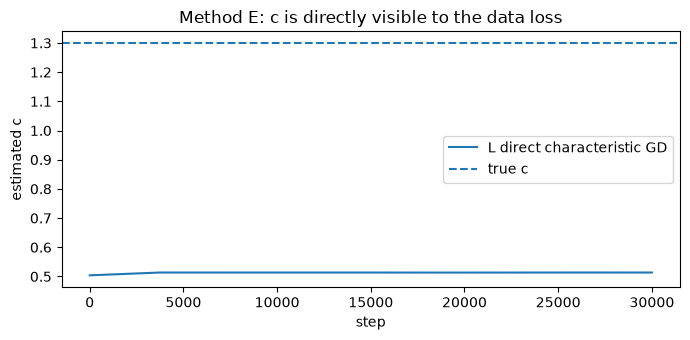


L. Characteristic-informed direct c optimization
------------------------------------------------
relative L2 error: 1.3767 -> poor: the high-frequency solution is not learned well.
c_est: 0.513533, c_true: 1.300000, |error|=0.7865 -> poor: c is not reliably identified.
boundary MSE: 0.000e+00
held-out PDE residual MSE: 0.000e+00


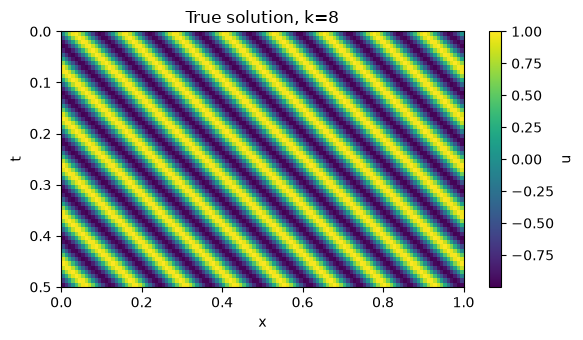

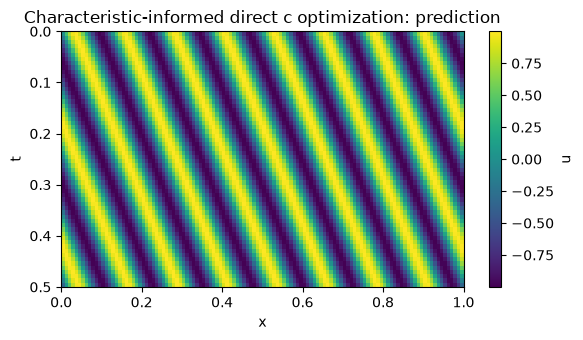

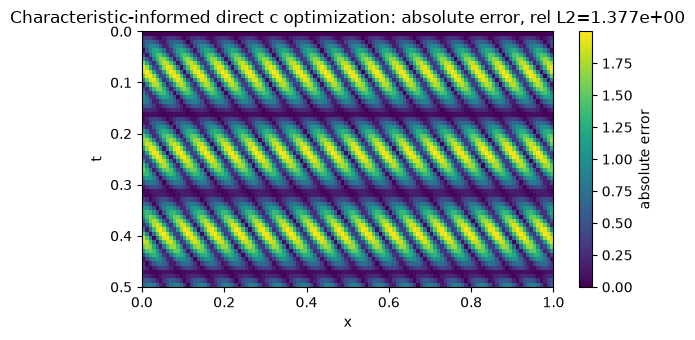

In [26]:
# Method E: characteristic-informed direct data loss for c.
def evaluate_characteristic_c(c_value, nx=120, nt=60):
    x = jnp.linspace(0.0, 1.0, nx)
    t = jnp.linspace(0.0, T_FINAL, nt)
    TT, XX = jnp.meshgrid(t, x, indexing="ij")
    xt = jnp.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)
    pred = characteristic_predict(c_value, xt).reshape(nt, nx)
    truth = exact_u(XX, TT)
    rel_l2 = jnp.linalg.norm(pred - truth) / jnp.linalg.norm(truth)
    max_abs = jnp.max(jnp.abs(pred - truth))

    # The characteristic formula exactly satisfies the advection equation for its own c.
    # It also satisfies the periodic boundary because the initial profile is periodic.
    return {
        "x": np.array(x),
        "t": np.array(t),
        "pred": np.array(pred),
        "truth": np.array(truth),
        "rel_l2": float(rel_l2),
        "max_abs": float(max_abs),
        "bc_mse": 0.0,
        "pde_mse_eval": 0.0,
        "c_est": float(c_value),
        "c_abs_error": abs(float(c_value) - C_TRUE),
    }

def train_characteristic_direct_gd(
    c_init=0.50,
    n_steps=CHAR_DIRECT_STEPS,
    lr_c=CHAR_DIRECT_LR_C,
):
    raw_c = inv_softplus(c_init)
    opt_c = adam_init(raw_c)

    @jax.jit
    def char_loss_from_raw(raw_c):
        c = positive(raw_c)
        pred = characteristic_predict(c, batch["xt_data"])
        return jnp.mean((pred - batch["y_data"])**2)

    @jax.jit
    def char_step(raw_c, opt_c):
        loss_value, grad_raw_c = jax.value_and_grad(char_loss_from_raw)(raw_c)
        new_raw_c, new_opt_c = adam_update(raw_c, grad_raw_c, opt_c, lr_c)
        # Keep the direct characteristic search in the same physically meaningful range
        # used by the coarse/fine landscape plots. This is still gradient descent, not grid search.
        clipped_c = jnp.clip(positive(new_raw_c), C_GRID_MIN, C_GRID_MAX)
        new_raw_c = inv_softplus(clipped_c)
        return new_raw_c, new_opt_c, loss_value

    history = []
    for step in range(1, n_steps + 1):
        raw_c, opt_c, loss_value = char_step(raw_c, opt_c)
        if step == 1 or step % PRINT_EVERY == 0 or step == n_steps:
            c_value = float(positive(raw_c))
            rec = {"step": step, "loss": float(loss_value), "c": c_value}
            history.append(rec)
            print(
                f"[L characteristic-direct] step={step:5d} "
                f"loss={rec['loss']:.3e} c={rec['c']:.6f}"
            )
    return float(positive(raw_c)), history

if RUN_CHARACTERISTIC_DIRECT_GD:
    print("\nMethod E: characteristic-informed direct data loss for c")
    c_char_direct, char_direct_hist = train_characteristic_direct_gd(c_init=0.50)
    char_direct_h = {k: np.array([h[k] for h in char_direct_hist]) for k in char_direct_hist[0].keys()}

    plt.figure(figsize=(7, 3.5))
    plt.plot(char_direct_h["step"], char_direct_h["c"], label="L direct characteristic GD")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Method E: c is directly visible to the data loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    char_direct_metrics = evaluate_characteristic_c(c_char_direct)
    print_interpretation("L. Characteristic-informed direct c optimization", char_direct_metrics)
    add_result(RESULTS, "L characteristic direct", char_direct_metrics, baseline=hard_metrics)
    plot_solution_comparison(char_direct_metrics, "Characteristic-informed direct c optimization")
else:
    print("Method E skipped. Set RUN_CHARACTERISTIC_DIRECT_GD=True to run it.")



Method F: loss curriculum

[M loss curriculum] stage: weak PDE, lambda_pde=0.01, steps=12000
[M loss curriculum: weak PDE] stage2 step=    1 loss=2.044e+01 pde=3.98e+02 ic=7.38e-01 data=9.08e-01 c=0.500000
[M loss curriculum: weak PDE] stage2 step= 3750 loss=2.039e-02 pde=1.26e+00 ic=5.11e-04 data=2.67e-04 c=0.621008
[M loss curriculum: weak PDE] stage2 step= 7500 loss=6.908e-03 pde=4.01e-01 ic=1.79e-04 data=1.10e-04 c=0.631617
[M loss curriculum: weak PDE] stage2 step=11250 loss=3.813e-04 pde=2.49e-02 ic=7.85e-06 data=5.42e-06 c=0.638379
[M loss curriculum: weak PDE] stage2 step=12000 loss=1.801e-03 pde=1.41e-01 ic=1.20e-05 data=2.76e-05 c=0.639329
[M loss curriculum: weak PDE] stage 2 finished in 75.7 seconds.

[M loss curriculum] stage: medium PDE, lambda_pde=0.1, steps=9000
[M loss curriculum: medium PDE] stage2 step=12001 loss=2.178e-02 pde=2.12e-01 ic=1.70e-05 data=4.17e-05 c=0.639348
[M loss curriculum: medium PDE] stage2 step=15750 loss=6.436e-04 pde=5.14e-03 ic=4.95e-06 data=

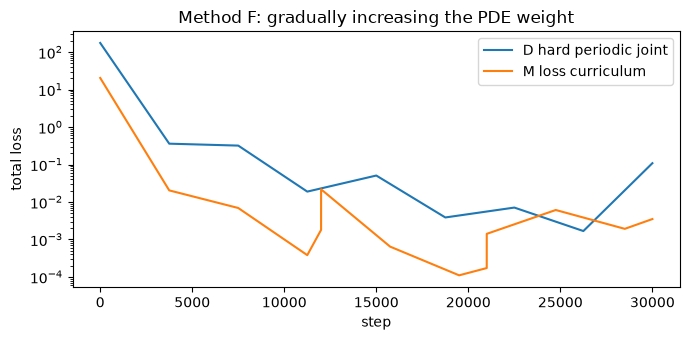

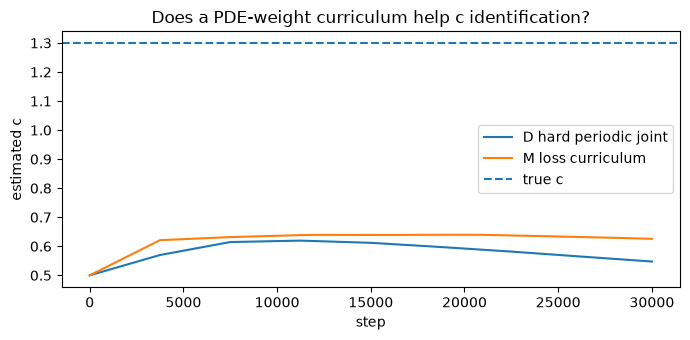


M. Loss curriculum
------------------
relative L2 error: 0.7176 -> poor: the high-frequency solution is not learned well.
c_est: 0.625563, c_true: 1.300000, |error|=0.6744 -> poor: c is not reliably identified.
boundary MSE: 9.004e-13
held-out PDE residual MSE: 6.944e+02


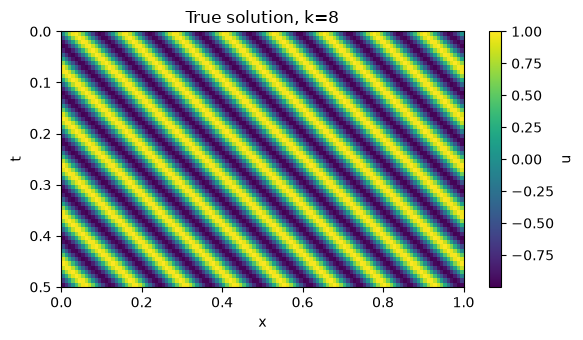

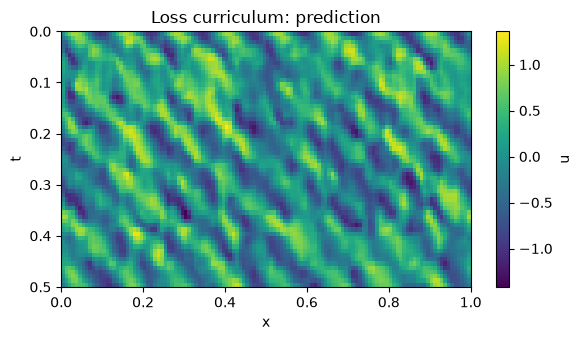

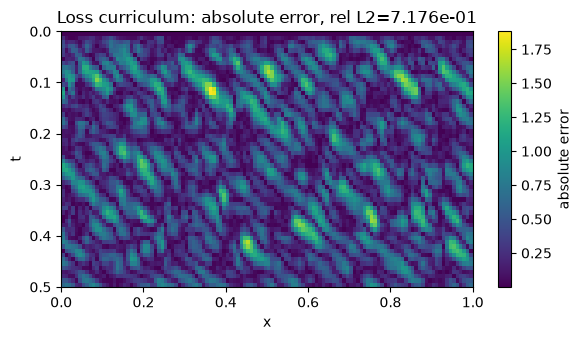

In [27]:
# Method F: loss curriculum for the PDE weight.
def train_loss_curriculum(
    model_name,
    seed=22,
    c_init=0.50,
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    schedule=LOSS_CURRICULUM_SCHEDULE,
):
    state, _ = init_state_and_optimizer(input_dim, seed=seed, c_init=c_init)
    history = []
    global_step = 0

    for stage_name, weights, n_stage_steps in schedule:
        print(
            f"\n[{model_name}] stage: {stage_name}, "
            f"lambda_pde={weights['pde']}, steps={n_stage_steps}"
        )
        state, hist_stage = continue_train_pinn(
            model_name=f"{model_name}: {stage_name}",
            state=state,
            apply_fn=apply_fn,
            weights=weights,
            n_steps=n_stage_steps,
            lr_params=1e-3,
            lr_c=1e-3,
            current_batch=batch,
            step_offset=global_step,
        )
        history.extend(hist_stage)
        global_step += n_stage_steps

    return state, history

if RUN_LOSS_CURRICULUM_EXPERIMENT:
    print("\nMethod F: loss curriculum")
    loss_curriculum_state, loss_curriculum_hist = train_loss_curriculum(
        model_name="M loss curriculum"
    )
    loss_curriculum_h = history_to_arrays(loss_curriculum_hist)

    plt.figure(figsize=(7, 3.5))
    plt.semilogy(hard_h["step"], hard_h["total"], label="D hard periodic joint")
    plt.semilogy(loss_curriculum_h["step"], loss_curriculum_h["total"], label="M loss curriculum")
    plt.xlabel("step")
    plt.ylabel("total loss")
    plt.title("Method F: gradually increasing the PDE weight")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(loss_curriculum_h["step"], loss_curriculum_h["c"], label="M loss curriculum")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Does a PDE-weight curriculum help c identification?")
    plt.legend()
    plt.tight_layout()
    plt.show()

    loss_curriculum_metrics = evaluate_on_grid(loss_curriculum_state, hard_periodic_apply)
    print_interpretation("M. Loss curriculum", loss_curriculum_metrics)
    add_result(RESULTS, "M loss curriculum", loss_curriculum_metrics, baseline=hard_metrics)
    plot_solution_comparison(loss_curriculum_metrics, "Loss curriculum")
else:
    print("Method F skipped. Set RUN_LOSS_CURRICULUM_EXPERIMENT=True to run it.")



### 14.5 Additional literature-inspired methods

The previous four methods test data pretraining, alternating parameter estimation, direct characteristic optimization, and a manually designed loss curriculum.  
The following three additions are closer to the strategies that appear repeatedly in inverse PINN and transport/advection--diffusion papers:

- **Method G: adaptive loss weighting.** Instead of fixing $\lambda_f,\lambda_{ic},\lambda_{bc},\lambda_d$, update them during training so that no single loss term dominates the gradient.
- **Method H: make $c$ visible to the data loss.** Ordinary PINN data loss $u_\theta(x,t)\approx u_{\rm data}$ does not directly depend on $c$. A transport-coordinate model uses $x-ct$ in the input, so data loss can update $c$ directly.
- **Method I: residual-based adaptive refinement (RAR).** Add new collocation points where the current PDE residual is large. This is common in PINN variants, but in this experiment it mainly tests whether poor collocation-point placement is the real cause of the wrong $c$.





Method G: adaptive gradient-balanced loss weighting
[N adaptive gradient weights] reweight at step 1: lambda_pde=0.81, lambda_ic=9.6, lambda_data=10.6
[N adaptive gradient weights] step=    1 loss=4.905e+02 pde=5.82e+02 ic=9.76e-01 data=9.14e-01 c=0.500000
[N adaptive gradient weights] step= 3750 loss=8.056e-01 pde=4.67e-01 ic=1.99e-03 data=3.85e-02 c=0.483373
[N adaptive gradient weights] step= 7500 loss=5.782e-02 pde=2.36e-02 ic=3.28e-04 data=3.36e-03 c=0.498549
[N adaptive gradient weights] reweight at step 7501: lambda_pde=0.658, lambda_ic=10.8, lambda_data=9.6
[N adaptive gradient weights] step=11250 loss=2.983e-02 pde=2.97e-02 ic=1.48e-04 data=9.04e-04 c=0.491088
[N adaptive gradient weights] step=15000 loss=1.968e-01 pde=2.89e-01 ic=2.84e-04 data=3.71e-04 c=0.473995
[N adaptive gradient weights] reweight at step 15001: lambda_pde=0.536, lambda_ic=9.36, lambda_data=11.1
[N adaptive gradient weights] step=18750 loss=2.124e-03 pde=2.83e-04 ic=5.71e-05 data=1.29e-04 c=0.459792
[N a

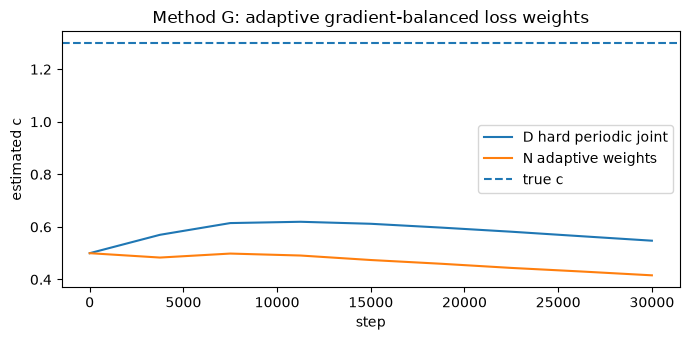

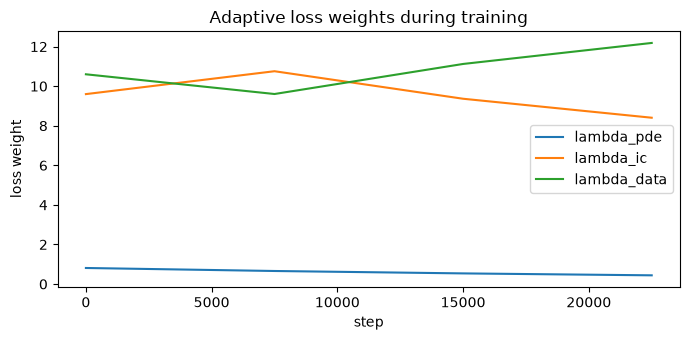


N. Adaptive gradient-balanced weighting
---------------------------------------
relative L2 error: 0.9581 -> poor: the high-frequency solution is not learned well.
c_est: 0.415752, c_true: 1.300000, |error|=0.8842 -> poor: c is not reliably identified.
boundary MSE: 1.935e-12
held-out PDE residual MSE: 6.060e+02


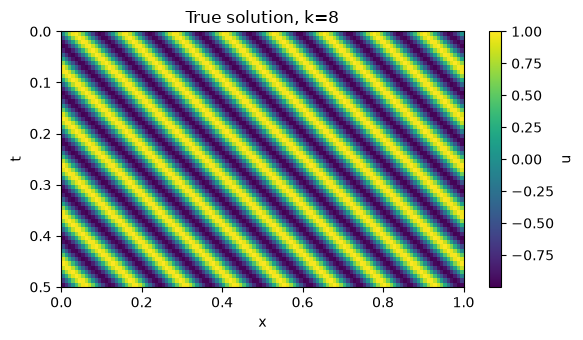

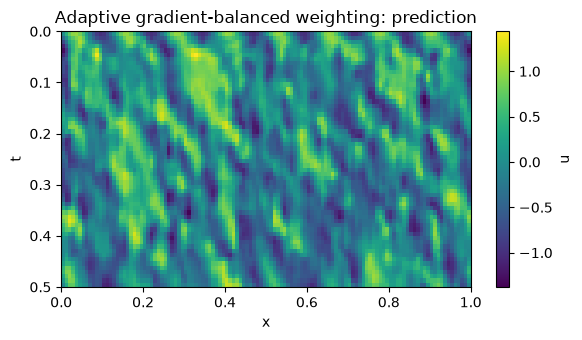

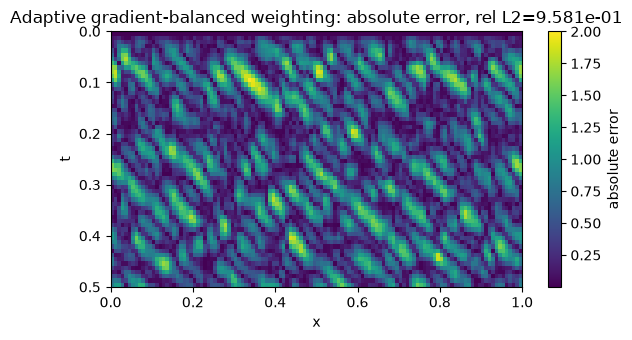

In [28]:

# Method G: adaptive gradient-balanced loss weighting.
#
# Motivation:
# In inverse PINNs, different loss components can have very different gradient scales.
# If the PDE residual becomes small too early while data/IC errors are still large,
# c may be trained using unreliable derivatives. This method periodically rebalances
# the loss weights using gradient norms with respect to the network parameters.
#
# Important:
# This is a simple and transparent implementation, not a full NTK adaptive weighting method.

def component_grad_norm_wrt_params(state, apply_fn, term, current_batch=batch):
    """Gradient norm of one unweighted loss component with respect to theta."""
    def component_loss_on_params(params):
        tmp_state = {"params": params, "raw_c": state["raw_c"]}
        return loss_parts(tmp_state, current_batch, apply_fn)[term]
    grad_params = jax.grad(component_loss_on_params)(state["params"])
    return float(tree_l2_norm(grad_params))

def update_gradient_balanced_weights(
    state,
    apply_fn,
    old_weights,
    base_weights=HARD_BC_WEIGHTS,
    current_batch=batch,
    smoothing=ADAPTIVE_WEIGHT_SMOOTHING,
    clip_range=ADAPTIVE_WEIGHT_CLIP,
):
    """Update weights so active loss terms have roughly comparable gradient norms."""
    active_terms = [k for k, v in base_weights.items() if v > 0.0]
    norms = {
        k: component_grad_norm_wrt_params(state, apply_fn, k, current_batch)
        for k in active_terms
    }

    # Use the average norm as the target. Terms with small gradients receive larger weights.
    target = float(np.mean([norms[k] for k in active_terms])) + ADAPTIVE_WEIGHT_EPS
    raw_weights = dict(base_weights)
    for k in active_terms:
        raw_weights[k] = base_weights[k] * target / (norms[k] + ADAPTIVE_WEIGHT_EPS)

    # Normalize so the total active weight stays comparable to the original scale.
    sum_base = sum(base_weights[k] for k in active_terms)
    sum_raw = sum(raw_weights[k] for k in active_terms)
    if sum_raw > 0:
        scale = sum_base / sum_raw
        for k in active_terms:
            raw_weights[k] *= scale

    lo, hi = clip_range
    new_weights = {}
    for k in base_weights.keys():
        if base_weights[k] == 0.0:
            new_weights[k] = 0.0
        else:
            proposed = float(np.clip(raw_weights[k], lo, hi))
            new_weights[k] = smoothing * float(old_weights[k]) + (1.0 - smoothing) * proposed

    return new_weights, norms

def train_adaptive_grad_weighting(
    model_name="N adaptive gradient weights",
    seed=23,
    c_init=0.50,
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    base_weights=HARD_BC_WEIGHTS,
    n_steps=N_STEPS,
    lr_params=1e-3,
    lr_c=1e-3,
    current_batch=batch,
):
    state, opt_state = init_state_and_optimizer(input_dim, seed=seed, c_init=c_init)
    weights = dict(base_weights)
    loss_fn = make_loss_fn(apply_fn, weights)
    train_step = make_train_step(loss_fn, lr_params, lr_c)

    history = []
    weight_history = []
    start = time.time()

    for step in range(1, n_steps + 1):
        if step == 1 or (step - 1) % ADAPTIVE_REWEIGHT_EVERY == 0:
            weights, norms = update_gradient_balanced_weights(
                state, apply_fn, weights, base_weights, current_batch
            )
            loss_fn = make_loss_fn(apply_fn, weights)
            train_step = make_train_step(loss_fn, lr_params, lr_c)
            weight_history.append({
                "step": step,
                "lambda_pde": weights["pde"],
                "lambda_ic": weights["ic"],
                "lambda_bc": weights["bc"],
                "lambda_data": weights["data"],
                "norm_pde": norms.get("pde", np.nan),
                "norm_ic": norms.get("ic", np.nan),
                "norm_bc": norms.get("bc", np.nan),
                "norm_data": norms.get("data", np.nan),
            })
            print(
                f"[{model_name}] reweight at step {step}: "
                f"lambda_pde={weights['pde']:.3g}, "
                f"lambda_ic={weights['ic']:.3g}, "
                f"lambda_data={weights['data']:.3g}"
            )

        state, opt_state, loss_value, parts = train_step(state, opt_state, current_batch)

        if step == 1 or step % PRINT_EVERY == 0 or step == n_steps:
            rec = {
                "step": step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] step={step:5d} "
                f"loss={rec['total']:.3e} pde={rec['pde']:.2e} "
                f"ic={rec['ic']:.2e} data={rec['data']:.2e} "
                f"c={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] finished in {elapsed:.1f} seconds.")
    return state, history, weight_history

if RUN_ADAPTIVE_GRAD_WEIGHTING:
    print("\nMethod G: adaptive gradient-balanced loss weighting")
    adaptive_state, adaptive_hist, adaptive_weight_hist = train_adaptive_grad_weighting()
    adaptive_h = history_to_arrays(adaptive_hist)

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(adaptive_h["step"], adaptive_h["c"], label="N adaptive weights")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Method G: adaptive gradient-balanced loss weights")
    plt.legend()
    plt.tight_layout()
    plt.show()

    if len(adaptive_weight_hist) > 0:
        wh = {k: np.array([r[k] for r in adaptive_weight_hist]) for k in adaptive_weight_hist[0].keys()}
        plt.figure(figsize=(7, 3.5))
        plt.plot(wh["step"], wh["lambda_pde"], label="lambda_pde")
        plt.plot(wh["step"], wh["lambda_ic"], label="lambda_ic")
        plt.plot(wh["step"], wh["lambda_data"], label="lambda_data")
        plt.xlabel("step")
        plt.ylabel("loss weight")
        plt.title("Adaptive loss weights during training")
        plt.legend()
        plt.tight_layout()
        plt.show()

    adaptive_metrics = evaluate_on_grid(adaptive_state, hard_periodic_apply)
    print_interpretation("N. Adaptive gradient-balanced weighting", adaptive_metrics)
    add_result(RESULTS, "N adaptive weights", adaptive_metrics, baseline=hard_metrics)
    plot_solution_comparison(adaptive_metrics, "Adaptive gradient-balanced weighting")
else:
    print("Method G skipped. Set RUN_ADAPTIVE_GRAD_WEIGHTING=True to run it.")


### 14.6 Method H: Put \(c\) into the model structure

The ordinary PINN uses

$$
u_\theta(x,t),
$$

so the data loss

$$
L_d^{\mathrm{std}}
=
\frac{1}{N_d}
\sum_i
\left|
u_\theta(x_i,t_i)-u_i
\right|^2
$$

does not contain \(c\) directly. Therefore,

$$
\frac{\partial L_d^{\mathrm{std}}}{\partial c}=0.
$$

This means that in the standard architecture, \(c\) is mainly updated through the PDE residual

$$
L_f
=
\frac{1}{N_f}
\sum_i
\left|
u_t(x_i,t_i)+c\,u_x(x_i,t_i)
\right|^2.
$$

For a high-frequency advection inverse problem, this can be unstable because early in training the network derivatives \(u_t\) and \(u_x\) are still inaccurate.

To make \(c\) visible to the observation data, we introduce the characteristic coordinate

$$
\xi = x - ct,
$$

and use the architecture

$$
u_\theta(x,t,c)
=
v_\theta(x-ct,t,c).
$$

Then the data loss becomes

$$
L_d^{\mathrm{vis}}(c)
=
\frac{1}{N_d}
\sum_i
\left|
v_\theta(x_i-c t_i,t_i,c)-u_i
\right|^2.
$$

Since \(c\) appears inside \(x_i-c t_i\), the data loss generally satisfies

$$
\frac{\partial L_d^{\mathrm{vis}}}{\partial c}
\neq 0.
$$

This is not a completely generic PINN because it uses the characteristic structure of the advection equation. However, it is still a trainable neural-network model: it does not substitute the exact formula \(u_0(x-ct)\), and it does not perform grid search.


Method H: c-visible transport-coordinate PINN
[O c-visible transport-coordinate PINN] step=    1 loss=1.083e+02 pde=9.55e+01 ic=6.34e-01 data=6.48e-01 c=0.500000
[O c-visible transport-coordinate PINN] step= 3750 loss=2.864e-01 pde=3.21e-02 ic=1.66e-03 data=2.38e-02 c=0.519095
[O c-visible transport-coordinate PINN] step= 7500 loss=2.707e-02 pde=2.69e-03 ic=3.21e-04 data=2.12e-03 c=0.518807
[O c-visible transport-coordinate PINN] step=11250 loss=7.758e-03 pde=8.57e-04 ic=1.08e-04 data=5.82e-04 c=0.518767
[O c-visible transport-coordinate PINN] step=15000 loss=3.073e-03 pde=4.26e-04 ic=6.26e-05 data=2.02e-04 c=0.518867
[O c-visible transport-coordinate PINN] step=18750 loss=3.953e-03 pde=2.56e-03 ic=4.51e-05 data=9.39e-05 c=0.519014
[O c-visible transport-coordinate PINN] step=22500 loss=7.103e-02 pde=6.89e-02 ic=1.11e-04 data=1.06e-04 c=0.519145
[O c-visible transport-coordinate PINN] step=26250 loss=5.948e-04 pde=1.47e-04 ic=2.40e-05 data=2.07e-05 c=0.519286
[O c-visible transport-co

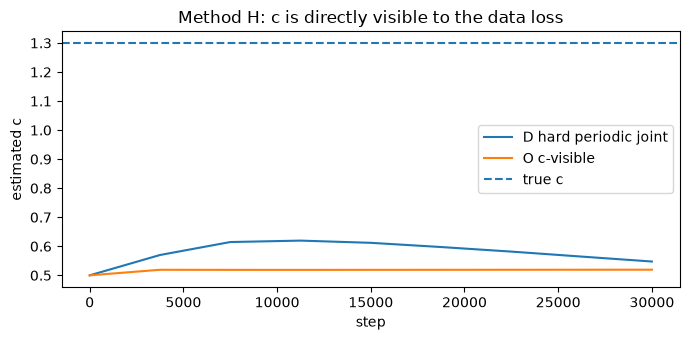


O. c-visible transport-coordinate PINN
--------------------------------------
relative L2 error: 1.0834 -> poor: the high-frequency solution is not learned well.
c_est: 0.519382, c_true: 1.300000, |error|=0.7806 -> poor: c is not reliably identified.
boundary MSE: 4.269e-12
held-out PDE residual MSE: 2.578e+02


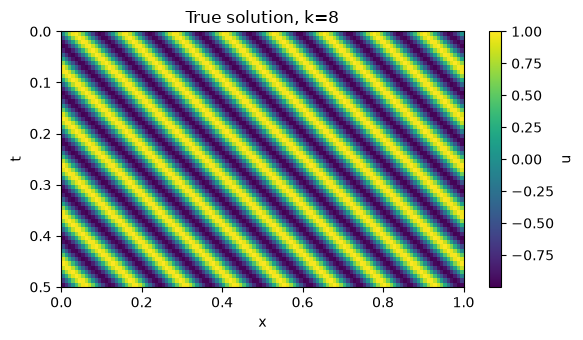

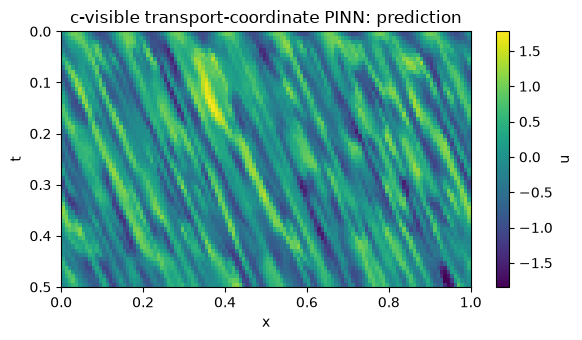

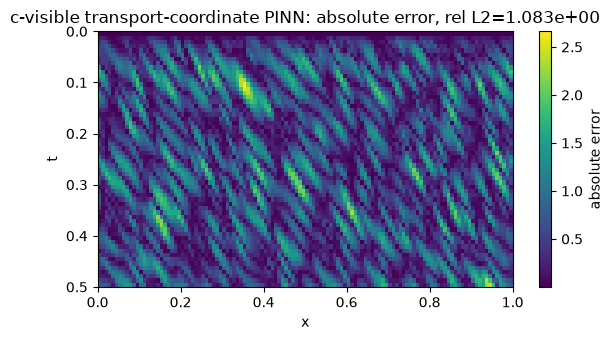

In [29]:

# Method H: make c directly visible to training through a transport-coordinate input.
#
# Standard PINN:
#     u_theta = u_theta(x,t)
#     data loss has no direct derivative with respect to c.
#
# Transport-coordinate PINN:
#     u_theta = v_theta(x - c t, t, c)
#     data loss now depends on c through the input x - c t.
#
# This is not a completely generic PINN architecture. It uses the characteristic
# structure of the advection equation, but it still trains a neural network instead
# of substituting the exact initial condition formula directly.

def transport_c_visible_embed(xt, c):
    x = xt[:, 0:1]
    t = xt[:, 1:2]
    z = x - c * t

    args_z = 2.0 * jnp.pi * z * FOURIER_FREQS[None, :]
    args_t = 2.0 * jnp.pi * t * FOURIER_FREQS[None, :]
    c_feat = jnp.ones_like(t) * c

    return jnp.concatenate(
        [
            t,
            c_feat,
            jnp.sin(args_z),
            jnp.cos(args_z),
            jnp.sin(args_t),
            jnp.cos(args_t),
        ],
        axis=1,
    )

TRANSPORT_C_VISIBLE_INPUT_DIM = int(2 + 4 * len(FOURIER_FREQS))

def transport_c_visible_predict(state, xt):
    c = positive(state["raw_c"])
    return mlp_apply(state["params"], transport_c_visible_embed(xt, c))


def data_loss_grad_wrt_raw_c_standard_for_diagnostic(
    raw_c,
    params,
    apply_fn=hard_periodic_apply,
    current_batch=batch,
):
    """For the standard architecture u_theta(x,t), data loss does not use c."""
    pred = apply_fn(params, current_batch["xt_data"])
    return jnp.mean((pred - current_batch["y_data"])**2)

def data_loss_grad_wrt_raw_c_c_visible_for_diagnostic(
    raw_c,
    params,
    current_batch=batch,
):
    """For u_theta(x,t,c)=v_theta(x-ct,t,c), data loss directly uses c."""
    tmp_state = {"params": params, "raw_c": raw_c}
    pred = transport_c_visible_predict(tmp_state, current_batch["xt_data"])
    return jnp.mean((pred - current_batch["y_data"])**2)

def print_c_visible_data_gradient_diagnostic(c_init=0.50, seed=24):
    """Print a direct check that Method H makes data loss depend on c."""
    std_state, _ = init_state_and_optimizer(
        HARD_PERIODIC_INPUT_DIM, seed=seed, c_init=c_init
    )
    vis_state, _ = init_state_and_optimizer(
        TRANSPORT_C_VISIBLE_INPUT_DIM, seed=seed, c_init=c_init
    )

    grad_std = jax.grad(
        lambda raw: data_loss_grad_wrt_raw_c_standard_for_diagnostic(
            raw, std_state["params"]
        )
    )(std_state["raw_c"])

    grad_vis = jax.grad(
        lambda raw: data_loss_grad_wrt_raw_c_c_visible_for_diagnostic(
            raw, vis_state["params"]
        )
    )(vis_state["raw_c"])

    print("Data-loss gradient check with respect to raw_c:")
    print(f"  standard u_theta(x,t):        d L_data / d raw_c = {float(grad_std): .3e}")
    print(f"  c-visible v_theta(x-ct,t,c): d L_data / d raw_c = {float(grad_vis): .3e}")
    print("  Interpretation: standard data loss cannot update c directly, but Method H can.")

def pde_residual_stateaware(state, xt, predict_state_fn):
    c = positive(state["raw_c"])

    def u_single(z):
        z = z.reshape(1, 2)
        return predict_state_fn(state, z)[0]

    grad_u = jax.vmap(jax.grad(u_single))(xt)
    u_x = grad_u[:, 0]
    u_t = grad_u[:, 1]
    return u_t + c * u_x

def loss_parts_stateaware(state, current_batch, predict_state_fn):
    r = pde_residual_stateaware(state, current_batch["xt_f"], predict_state_fn)
    loss_pde = jnp.mean(r**2)

    pred_ic = predict_state_fn(state, current_batch["xt_ic"])
    loss_ic = jnp.mean((pred_ic - current_batch["y_ic"])**2)

    pred_b0 = predict_state_fn(state, current_batch["xt_b0"])
    pred_b1 = predict_state_fn(state, current_batch["xt_b1"])
    loss_bc = jnp.mean((pred_b0 - pred_b1)**2)

    pred_data = predict_state_fn(state, current_batch["xt_data"])
    loss_data = jnp.mean((pred_data - current_batch["y_data"])**2)

    return {
        "pde": loss_pde,
        "ic": loss_ic,
        "bc": loss_bc,
        "data": loss_data,
    }

def make_loss_fn_stateaware(predict_state_fn, weights):
    def loss_fn(state, current_batch):
        parts = loss_parts_stateaware(state, current_batch, predict_state_fn)
        total = (
            weights["pde"] * parts["pde"]
            + weights["ic"] * parts["ic"]
            + weights["bc"] * parts["bc"]
            + weights["data"] * parts["data"]
        )
        aux = dict(parts)
        aux["total"] = total
        aux["c"] = positive(state["raw_c"])
        return total, aux
    return loss_fn

def make_train_step_stateaware(loss_fn, lr_params, lr_c):
    @jax.jit
    def train_step(state, opt_state, current_batch):
        (loss_value, parts), grads = jax.value_and_grad(loss_fn, has_aux=True)(state, current_batch)

        new_params, new_opt_params = adam_update(
            state["params"], grads["params"], opt_state["params"], lr_params
        )
        new_raw_c, new_opt_c = adam_update(
            state["raw_c"], grads["raw_c"], opt_state["raw_c"], lr_c
        )

        # Keep c in a physically meaningful range during this diagnostic experiment.
        new_c = jnp.clip(positive(new_raw_c), C_GRID_MIN, C_GRID_MAX)
        new_raw_c = inv_softplus(new_c)

        new_state = {"params": new_params, "raw_c": new_raw_c}
        new_opt_state = {"params": new_opt_params, "raw_c": new_opt_c}
        return new_state, new_opt_state, loss_value, parts
    return train_step

def train_transport_c_visible_pinn(
    model_name="O c-visible transport-coordinate PINN",
    seed=24,
    c_init=0.50,
    n_steps=TRANSPORT_C_VISIBLE_STEPS,
    weights=TRANSPORT_C_VISIBLE_WEIGHTS,
    lr_params=TRANSPORT_C_VISIBLE_LR_PARAMS,
    lr_c=TRANSPORT_C_VISIBLE_LR_C,
    current_batch=batch,
):
    state, opt_state = init_state_and_optimizer(
        TRANSPORT_C_VISIBLE_INPUT_DIM, seed=seed, c_init=c_init
    )
    loss_fn = make_loss_fn_stateaware(transport_c_visible_predict, weights)
    train_step = make_train_step_stateaware(loss_fn, lr_params, lr_c)

    history = []
    start = time.time()
    for step in range(1, n_steps + 1):
        state, opt_state, loss_value, parts = train_step(state, opt_state, current_batch)

        if step == 1 or step % PRINT_EVERY == 0 or step == n_steps:
            rec = {
                "step": step,
                "total": float(parts["total"]),
                "pde": float(parts["pde"]),
                "ic": float(parts["ic"]),
                "bc": float(parts["bc"]),
                "data": float(parts["data"]),
                "c": float(parts["c"]),
            }
            history.append(rec)
            print(
                f"[{model_name}] step={step:5d} "
                f"loss={rec['total']:.3e} pde={rec['pde']:.2e} "
                f"ic={rec['ic']:.2e} data={rec['data']:.2e} "
                f"c={rec['c']:.6f}"
            )

    elapsed = time.time() - start
    print(f"[{model_name}] finished in {elapsed:.1f} seconds.")
    return state, history

def evaluate_on_grid_stateaware(state, predict_state_fn, nx=120, nt=60, n_res_eval=N_RES_EVAL):
    x = jnp.linspace(0.0, 1.0, nx)
    t = jnp.linspace(0.0, T_FINAL, nt)
    TT, XX = jnp.meshgrid(t, x, indexing="ij")
    xt = jnp.stack([XX.reshape(-1), TT.reshape(-1)], axis=1)

    pred = predict_state_fn(state, xt).reshape(nt, nx)
    truth = exact_u(XX, TT)
    rel_l2 = jnp.linalg.norm(pred - truth) / jnp.linalg.norm(truth)
    max_abs = jnp.max(jnp.abs(pred - truth))

    t_bc = jnp.linspace(0.0, T_FINAL, 100).reshape(-1, 1)
    xt0 = jnp.concatenate([jnp.zeros_like(t_bc), t_bc], axis=1)
    xt1 = jnp.concatenate([jnp.ones_like(t_bc), t_bc], axis=1)
    bc_mse = jnp.mean((predict_state_fn(state, xt0) - predict_state_fn(state, xt1))**2)

    key_eval = random.PRNGKey(202408)
    key_x, key_t = random.split(key_eval)
    x_r = random.uniform(key_x, (n_res_eval, 1), minval=0.0, maxval=1.0)
    t_r = random.uniform(key_t, (n_res_eval, 1), minval=0.0, maxval=T_FINAL)
    xt_r = jnp.concatenate([x_r, t_r], axis=1)
    r_eval = pde_residual_stateaware(state, xt_r, predict_state_fn)
    pde_mse_eval = jnp.mean(r_eval**2)

    c_est = float(positive(state["raw_c"]))
    return {
        "x": np.array(x),
        "t": np.array(t),
        "pred": np.array(pred),
        "truth": np.array(truth),
        "rel_l2": float(rel_l2),
        "max_abs": float(max_abs),
        "bc_mse": float(bc_mse),
        "pde_mse_eval": float(pde_mse_eval),
        "c_est": c_est,
        "c_abs_error": abs(c_est - C_TRUE),
    }

if RUN_TRANSPORT_C_VISIBLE_PINN:
    print("\nMethod H: c-visible transport-coordinate PINN")
    transport_c_visible_state, transport_c_visible_hist = train_transport_c_visible_pinn()
    transport_c_visible_h = history_to_arrays(transport_c_visible_hist)

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(transport_c_visible_h["step"], transport_c_visible_h["c"], label="O c-visible")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Method H: c is directly visible to the data loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    transport_c_visible_metrics = evaluate_on_grid_stateaware(
        transport_c_visible_state, transport_c_visible_predict
    )
    print_interpretation("O. c-visible transport-coordinate PINN", transport_c_visible_metrics)
    add_result(RESULTS, "O c-visible transport PINN", transport_c_visible_metrics, baseline=hard_metrics)
    plot_solution_comparison(transport_c_visible_metrics, "c-visible transport-coordinate PINN")
else:
    print("Method H skipped. Set RUN_TRANSPORT_C_VISIBLE_PINN=True to run it.")


In [30]:

# Method I: residual-based adaptive refinement (RAR).
#
# RAR adds collocation points where the current PDE residual is large.
# This often helps forward PINN accuracy. In this inverse problem, it tests
# whether the wrong c is mainly caused by poor residual-point coverage.

def add_rar_points_to_batch(
    state,
    apply_fn,
    current_batch=batch,
    seed=202409,
    n_candidates=RAR_CANDIDATES,
    n_add=RAR_ADD,
):
    key = random.PRNGKey(seed)
    key_x, key_t = random.split(key)
    x_cand = random.uniform(key_x, (n_candidates, 1), minval=0.0, maxval=1.0)
    t_cand = random.uniform(key_t, (n_candidates, 1), minval=0.0, maxval=T_FINAL)
    xt_cand = jnp.concatenate([x_cand, t_cand], axis=1)

    res_abs = jnp.abs(pde_residual(state, xt_cand, apply_fn))
    top_idx = jnp.argsort(-res_abs)[: min(n_add, n_candidates)]
    xt_add = xt_cand[top_idx]

    new_batch = dict(current_batch)
    new_batch["xt_f"] = jnp.concatenate([current_batch["xt_f"], xt_add], axis=0)
    return new_batch, xt_add, res_abs[top_idx]

def train_rar_experiment(
    model_name="P RAR hard-periodic PINN",
    seed=25,
    c_init=0.50,
    apply_fn=hard_periodic_apply,
    input_dim=HARD_PERIODIC_INPUT_DIM,
    weights=HARD_BC_WEIGHTS,
):
    state, _ = init_state_and_optimizer(input_dim, seed=seed, c_init=c_init)

    print(f"\n[{model_name}] stage 1: train on original collocation points")
    state, hist1 = continue_train_pinn(
        model_name=f"{model_name} pre-RAR",
        state=state,
        apply_fn=apply_fn,
        weights=weights,
        n_steps=RAR_PRETRAIN_STEPS,
        lr_params=1e-3,
        lr_c=1e-3,
        current_batch=batch,
        step_offset=0,
    )

    print(f"\n[{model_name}] select new residual points")
    rar_batch, xt_add, res_top = add_rar_points_to_batch(state, apply_fn, batch)
    print("  original N_F:", batch["xt_f"].shape[0])
    print("  added RAR points:", xt_add.shape[0])
    print("  new N_F:", rar_batch["xt_f"].shape[0])
    print("  largest selected residual:", float(jnp.max(res_top)))

    plt.figure(figsize=(5, 4))
    plt.scatter(np.array(batch["xt_f"][:, 0]), np.array(batch["xt_f"][:, 1]), s=8, alpha=0.35, label="original residual points")
    plt.scatter(np.array(xt_add[:, 0]), np.array(xt_add[:, 1]), s=12, label="RAR added points")
    plt.xlabel("x")
    plt.ylabel("t")
    plt.title("RAR: added collocation points")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n[{model_name}] stage 2: continue training after RAR")
    state, hist2 = continue_train_pinn(
        model_name=f"{model_name} post-RAR",
        state=state,
        apply_fn=apply_fn,
        weights=weights,
        n_steps=RAR_FINETUNE_STEPS,
        lr_params=1e-3,
        lr_c=1e-3,
        current_batch=rar_batch,
        step_offset=RAR_PRETRAIN_STEPS,
    )

    return state, hist1 + hist2

if RUN_RAR_EXPERIMENT:
    print("\nMethod I: residual-based adaptive refinement")
    rar_state, rar_hist = train_rar_experiment()
    rar_h = history_to_arrays(rar_hist)

    plt.figure(figsize=(7, 3.5))
    plt.plot(hard_h["step"], hard_h["c"], label="D hard periodic joint")
    plt.plot(rar_h["step"], rar_h["c"], label="P RAR")
    plt.axhline(C_TRUE, linestyle="--", label="true c")
    plt.xlabel("step")
    plt.ylabel("estimated c")
    plt.title("Method I: does RAR help identify c?")
    plt.legend()
    plt.tight_layout()
    plt.show()

    rar_metrics = evaluate_on_grid(rar_state, hard_periodic_apply)
    print_interpretation("P. Residual-based adaptive refinement", rar_metrics)
    add_result(RESULTS, "P RAR", rar_metrics, baseline=hard_metrics)
    plot_solution_comparison(rar_metrics, "Residual-based adaptive refinement")
else:
    print("Method I skipped. Set RUN_RAR_EXPERIMENT=True to run it.")


Method I skipped. Set RUN_RAR_EXPERIMENT=True to run it.



This high-frequency inverse problem is dominated by the nonconvex phase landscape of $c$, so a problem-specific initialization or parameterization is not merely helpful but close to necessary.


## 15. Characteristic Loss Landscape and Learned Parameters

Here we mark the final values of $c$ obtained by different PINN methods on the same characteristic loss landscape.

Mathematically, we fix the data $(x_i,t_i,u_i)$ and treat only $c$ as the variable:

$$
L_{\mathrm{char}}(c)
=
\frac1N\sum_i
\left|
\sin(2\pi k(x_i-c t_i))-u_i
\right|^2.
$$



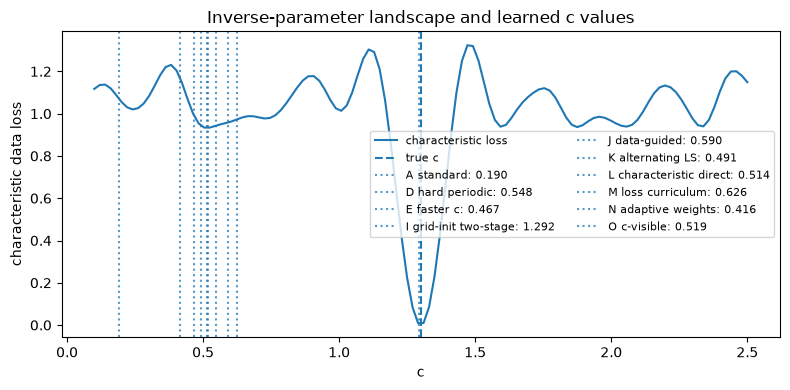

In [31]:
def plot_characteristic_landscape_with_estimates():
    plt.figure(figsize=(8, 4))
    plt.plot(np.array(c_grid_coarse), np.array(loss_grid_coarse), label="characteristic loss")
    plt.axvline(C_TRUE, linestyle="--", label="true c")

    estimates = [
        ("A standard", std_metrics["c_est"]),
        ("D hard periodic", hard_metrics["c_est"]),
        ("E faster c", hard_fastc_metrics["c_est"]),
    ]
    if "grid_init_metrics" in globals():
        estimates.append(("I grid-init two-stage", grid_init_metrics["c_est"]))
    if "data_guided_metrics" in globals():
        estimates.append(("J data-guided", data_guided_metrics["c_est"]))
    if "alternating_metrics" in globals():
        estimates.append(("K alternating LS", alternating_metrics["c_est"]))
    if "char_direct_metrics" in globals():
        estimates.append(("L characteristic direct", char_direct_metrics["c_est"]))
    if "loss_curriculum_metrics" in globals():
        estimates.append(("M loss curriculum", loss_curriculum_metrics["c_est"]))
    if "adaptive_metrics" in globals():
        estimates.append(("N adaptive weights", adaptive_metrics["c_est"]))
    if "transport_c_visible_metrics" in globals():
        estimates.append(("O c-visible", transport_c_visible_metrics["c_est"]))
    if "rar_metrics" in globals():
        estimates.append(("P RAR", rar_metrics["c_est"]))
    if "multistart_metrics" in globals():
        estimates.append(("multi-start", multistart_metrics["c_est"]))
    if "curriculum_metrics" in globals():
        estimates.append(("frequency curriculum", curriculum_metrics["c_est"]))

    for name, c_value in estimates:
        plt.axvline(c_value, linestyle=":", alpha=0.75, label=f"{name}: {c_value:.3f}")

    plt.xlabel("c")
    plt.ylabel("characteristic data loss")
    plt.title("Inverse-parameter landscape and learned c values")
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

plot_characteristic_landscape_with_estimates()


## 16. Final Conclusions

1. **A standard joint PINN is unreliable for this high-frequency inverse problem.** A decreasing training loss does not guarantee correct identification of the wave speed $c$.
2. **Fourier features and hard periodic embedding address only part of the problem.** Fourier features improve high-frequency representation, while hard periodic embedding structurally enforces the periodic boundary condition. However, neither one necessarily places $c$ in the correct inverse-parameter basin.
3. **The characteristic landscape explains the difficulty of $c$.** Because the solution contains a high-frequency phase $2\pi k(x-ct)$, different values of $c$ can produce misleadingly similar observations at sparse points.
4. **Grid initialization plus two-stage training is the main inverse-specific method.** It first uses the physical characteristic structure to find a reasonable value of $c$, then trains the network, and finally fine-tunes $c$.
5. **The literature-inspired experiments clarify which generic PINN tricks are sufficient or insufficient.** Data-guided pretraining, alternating LS updates, direct characteristic optimization, loss curriculum, adaptive loss weighting, c-visible transport-coordinate training, and RAR test different explanations: early derivative error, joint-optimization instability, indirect dependence of data loss on $c$, loss imbalance, gradient imbalance, missing parameter visibility, and residual-point placement.


## 17. References 

1. **Physics-informed neural networks**  
   M. Raissi, P. Perdikaris, and G. E. Karniadakis, *Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations*, Journal of Computational Physics, 2019.  
   Used to support the PINN loss and the inverse-parameter training framework.

2. **Neural Tangent Kernel**  
   A. Jacot, F. Gabriel, and C. Hongler, *Neural Tangent Kernel: Convergence and Generalization in Neural Networks*, NeurIPS, 2018.  
   Used to support the diagnostic idea of the empirical output NTK and the PDE residual NTK.

3. **Fourier features**  
   M. Tancik et al., *Fourier Features Let Networks Learn High Frequency Functions in Low Dimensional Domains*, NeurIPS, 2020.  
   Used to explain why sine/cosine input features can improve the representation of high-frequency functions.

4. **Gradient pathologies and adaptive loss balancing in PINNs**  
   S. Wang, Y. Teng, and P. Perdikaris, *Understanding and mitigating gradient flow pathologies in physics-informed neural networks*, SIAM Journal on Scientific Computing, 2021.  
   R. Bischof and M. A. Kraus, *Multi-Objective Loss Balancing for Physics-Informed Deep Learning*, 2021.  
   Used to motivate gradient-norm diagnosis and the adaptive loss-weighting experiment.

5. **Data-guided PINNs for inverse problems**  
   W. Zhou and Y. F. Xu, *Data-Guided Physics-Informed Neural Networks for Solving Inverse Problems in Partial Differential Equations*, 2024.  
   Used to motivate the data-guided pretraining and fine-tuning experiment.

6. **Advection--diffusion / transport inverse PINNs**  
   Examples in the recent PINN literature often solve advection--diffusion, advection--dispersion--reaction, or transport inverse problems by combining observation loss, PDE residual loss, adaptive weighting, gradient scaling, Adam--L-BFGS training, or improved collocation strategies.  
   These papers motivate the adaptive weighting, RAR, and c-visible parameterization tests, but the present notebook differs because it studies a pure high-frequency advection equation where the unknown speed $c$ controls the phase $x-ct$.

7. **Characteristic structure of the advection equation**  
   The identity $u(x,t;c)=u_0(x-ct)$ motivates the characteristic grid initialization, characteristic direct optimization, and c-visible transport-coordinate model. These are problem-specific methods rather than generic PINN tricks.
